In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Etape 1 : Exploration des données + DataViz’

Attendue de cette étape :

- Votre première tâche consistera à définir le contexte et le périmètre du projet : j’attends que vous preniez vraiment le temps de bien comprendre le projet et de vous renseigner au mieux sur les notions que celui-ci va introduire.

- Il faudra ensuite prendre en main et découvrir votre jeu de données et faire une analyse presque exhaustive de celui-ci afin de mettre en lumière la structure, les difficultés et eventuels biais du dataset.

J’attendrai également au moins 5 représentations graphiques construites à partir de votre jeu de données, visuelles et surtout pertinentes. Pour chacune d’elle j’attendrai :
- Un commentaire précis, qui analyse la figure et apporte un avis “métier”.
- Une validation du constat par des manipulations de données, ou un test statistique.

## Contexte et périmètre du projet

Le projet "Compagnon_Immo" a pour but de développer une solution innovante permettant aux acheteurs et investisseurs immobiliers d’explorer, comparer et estimer les prix des logements sur différents territoires.

Dans un premier temps nous nous focalisons sur l'analyse des données immobilières du Haut-Rhin (Département 68). Ces données comportent des informations sur des biens en locations et en ventes dans le département entre 2019 et 2023.

Nous avons à notre disposition une cinquentaine de variables pour prédire notre cible, le prix du bien.
Ces variables décrives les propriétés des biens comme leur surface, le nombre de pièces, d'étages etc ... mais aussi bien leur années de construction et leur emplacement géographique. Tout ces éléments impactent le prix du bien, tachons maintenant d'identifier les variables pertinantes pour notre analyse.

### Description des jeux de données

Voici un descriptif des variables disponibles dans nos jeux de données.

In [119]:
df_locations = pd.read_csv('data/ech_annonces_locations_68.csv', sep=';', index_col='idannonce')

print("Shape : ", df_locations.shape)

print('Variables numériques du jeu de données des locations')

display(df_locations.describe())

print('Variables catégorielles du jeu de données des locations')

display(df_locations.describe(include='O'))

print("Nombre d'éléments vides par variables dans le jeu de donnés des locations")
display(df_locations.isna().sum())

Shape :  (11702, 51)
Variables numériques du jeu de données des locations


,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,prix_terrain,mensualiteFinance,balcon,eau,...,nb_logements_copro,charges_copro,duree_int,INSEE_COM,IRIS,CODE_IRIS,GRD_QUART,UU2010,REG,DEP
count,11702.000000,11702.000000,507.000000,11702.000000,11702.000000,0.0,0.0,11702.0,11702.000000,11702.000000,...,9.000000,0.0,11448.000000,11702.000000,11702.000000,1.170200e+04,1.170200e+04,11702.000000,11702.000000,11702.000000
mean,1.840711,65.150060,564.100118,2.820629,714.543924,NaN,NaN,0.0,0.186977,0.286789,...,18.666667,NaN,-207.466632,68191.909844,244.231499,6.819193e+08,6.819192e+06,68324.462400,44.018886,67.999316
std,24.546138,30.798055,776.823114,1.219675,286.924335,NaN,NaN,0.0,0.459904,0.465137,...,42.272923,NaN,422.747918,814.069476,385.032725,8.140732e+06,8.140730e+04,3166.426849,1.763585,0.807832
min,-2.000000,7.000000,1.710000,1.000000,1.000000,NaN,NaN,0.0,0.000000,0.000000,...,0.000000,NaN,-1125.000000,6088.000000,0.000000,6.088010e+07,6.088010e+05,758.000000,11.000000,6.000000
25%,0.000000,45.000000,200.000000,2.000000,531.000000,NaN,NaN,0.0,0.000000,0.000000,...,3.000000,NaN,-757.000000,68093.000000,0.000000,6.809300e+08,6.809300e+06,68402.000000,44.000000,68.000000
50%,1.000000,62.000000,455.000000,3.000000,660.000000,NaN,NaN,0.0,0.000000,0.000000,...,5.000000,NaN,15.000000,68224.000000,103.000000,6.822402e+08,6.822401e+06,68501.000000,44.000000,68.000000
75%,2.000000,79.000000,700.000000,3.000000,820.000000,NaN,NaN,0.0,0.000000,1.000000,...,8.000000,NaN,41.000000,68271.000000,202.000000,6.827101e+08,6.827101e+06,68701.000000,44.000000,68.000000
max,999.000000,450.000000,10198.000000,13.000000,3287.000000,NaN,NaN,0.0,12.000000,3.000000,...,131.000000,NaN,504.000000,86214.000000,6220.000000,8.621401e+08,8.621401e+06,86601.000000,93.000000,86.000000


Variables catégorielles du jeu de données des locations


,type_annonceur,typedebien,typedetransaction,dpeL,annonce_exclusive,cave,exposition,ges_class,videophone,porte_digicode,ascenseur,chauffage_energie,chauffage_systeme,chauffage_mode,categorie_annonceur,logement_neuf,typedebien_lite,date,TYP_IRIS_x,TYP_IRIS_y
count,11702,11702,11702,11702,11702,4997,11702,9424,510,1978,6587,5635,3614,7508,11702,11340,11702,11702,11702,11702
unique,2,3,2,10,3,2,25,9,2,2,2,5,9,6,3,2,3,49,3,3
top,pr,a,l,D,0,True,0,C,False,False,False,Gaz,Radiateur,Individuel,a,n,a,2020-01,H,H
freq,11595,10677,11675,2894,11276,2910,10708,2201,441,1767,3561,3638,3148,5865,11659,11339,10677,571,8501,8498


Nombre d'éléments vides par variables dans le jeu de donnés des locations


type_annonceur                 0
typedebien                     0
typedetransaction              0
etage                          0
surface                        0
surface_terrain            11195
nb_pieces                      0
prix_bien                      0
prix_maison                11702
prix_terrain               11702
mensualiteFinance              0
balcon                         0
eau                            0
bain                           0
dpeL                           0
dpeC                        2867
mapCoordonneesLatitude         0
mapCoordonneesLongitude        0
annonce_exclusive              0
nb_etages                   5071
parking                    11702
places_parking              7620
cave                        6705
exposition                     0
ges_class                   2278
annee_construction          9427
nb_toilettes                6911
nb_terraces                10137
videophone                 11192
porte_digicode              9724
surface_ba

In [120]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

print("Shape : ", df_ventes.shape)

print('Variables numériques du jeu de données des vesntes')

display(df_ventes.describe())

print('Variables catégorielles du jeu de données des ventes')

display(df_ventes.describe(include='O'))

print("Nombre d'éléments vides par variables dans le jeu de donnés des ventes")
display(df_ventes.isna().sum())

Shape :  (27737, 58)
Variables numériques du jeu de données des vesntes


,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,prix_terrain,mensualiteFinance,balcon,eau,...,UU2010,REG,DEP,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
count,27737.00000,27737.000000,11444.000000,27737.000000,2.773700e+04,437.000000,437.000000,27737.000000,27737.000000,27737.000000,...,27737.000000,27737.0,27737.0,17485.000000,17485.000000,17485.000000,19650.000000,19650.000000,19650.000000,27737.000000
mean,1.39204,108.343188,1017.414037,4.526301,2.773427e+05,213134.462243,89757.581236,13.232433,0.167610,0.283809,...,68370.913834,44.0,68.0,10.779532,17.011210,0.056380,10.639302,151.035929,0.056315,2624.974439
std,26.84627,60.845498,6694.219735,2.029696,1.861352e+05,71437.516537,47633.302968,139.079554,0.415649,0.541601,...,269.815128,0.0,0.0,2.066664,29.391785,0.083427,1.946427,252.454136,0.081040,1195.389487
min,-1.00000,2.000000,1.000000,1.000000,1.076000e+03,86000.000000,1.000000,0.000000,0.000000,0.000000,...,68000.000000,44.0,68.0,3.080000,1.000000,0.003000,4.780000,1.000000,0.003000,15.590000
25%,0.00000,71.000000,378.000000,3.000000,1.590000e+05,156500.000000,62000.000000,0.000000,0.000000,0.000000,...,68112.000000,44.0,68.0,9.440000,2.000000,0.038000,9.320000,3.000000,0.038000,1870.000000
50%,0.00000,95.000000,589.000000,4.000000,2.420000e+05,199620.000000,87000.000000,0.000000,0.000000,0.000000,...,68403.000000,44.0,68.0,10.530000,6.000000,0.048000,10.380000,18.000000,0.048000,2580.650000
75%,1.00000,130.000000,875.000000,5.000000,3.470000e+05,250010.000000,115800.000000,0.000000,0.000000,1.000000,...,68701.000000,44.0,68.0,11.950000,19.000000,0.066000,11.810000,190.000000,0.066000,3268.480000
max,999.00000,980.000000,431600.000000,43.000000,3.380000e+06,514999.000000,320000.000000,7715.000000,8.000000,10.000000,...,68701.000000,44.0,68.0,23.730000,212.000000,10.496000,23.730000,960.000000,10.773000,79500.000000


Variables catégorielles du jeu de données des ventes


,type_annonceur,typedebien,typedetransaction,dpeL,annonce_exclusive,parking,cave,exposition,ges_class,videophone,...,ascenseur,chauffage_energie,chauffage_systeme,chauffage_mode,categorie_annonceur,logement_neuf,typedebien_lite,date,TYP_IRIS_x,TYP_IRIS_y
count,27737,27737,27737,27737,27737,27,13247,27737,19716,135,...,8750,12571,7627,13610,27737,26998,27737,27737,27737,27737
unique,1,5,3,10,3,2,2,35,9,2,...,2,10,13,6,6,2,3,51,3,2
top,pr,m,v,D,Oui,True,True,0,D,True,...,True,Gaz,Radiateur,Individuel,a,n,m,2020-01,H,H
freq,27737,13288,27369,6011,11754,21,8626,21392,3943,75,...,4994,7787,6254,11186,21044,23391,13938,1383,14065,14082


Nombre d'éléments vides par variables dans le jeu de donnés des ventes


type_annonceur                 0
typedebien                     0
typedetransaction              0
etage                          0
surface                        0
surface_terrain            16293
nb_pieces                      0
prix_bien                      0
prix_maison                27300
prix_terrain               27300
mensualiteFinance              0
balcon                         0
eau                            0
bain                           0
dpeL                           0
dpeC                       10587
mapCoordonneesLatitude         0
mapCoordonneesLongitude        0
annonce_exclusive              0
nb_etages                  12878
parking                    27710
places_parking             17568
cave                       14490
exposition                     0
ges_class                   8021
annee_construction         18279
nb_toilettes               12301
nb_terraces                23638
videophone                 27602
porte_digicode             23473
surface_ba

Variables communes au jeu de données de locations et de ventes :

| Nom de la variable + description |
| --- |
| La variable catégorielle 'type_annonceur' contient les modalités pr et pa pour PRO et PARTICULIER. |
| La variable catégorielle 'typedebien' contient les modalités m, a, l, mn et an pour Maison, Appartement, Lot, (Maison ?) et (Appartement ?). |
| La variable catégorielle 'typedetransaction' contient les modalités l, lt, v, vp et pi pour Location, (lt : type de location ?), Vente, (vp : type de vente?) et (pi ?). |
| La variable numérique 'etage' correspond à l'étage où se situe le bien. Pour les locations : les valeurs vont de -2 à 999 mais la médiane est de 1 et la moyenne de 1.8. Pour les ventes : les valeurs vont de -1 à 999 mais la médiane est de 0 et la moyenne de 1.3. |
| La variable numérique 'surface' correspond à la superficie en m² du bien. Pour les locations : les valeurs vont de 7 à 450 avec une médiane de 62 et une moyenne de 65.1. Pour les ventes : les valeurs vont de 2 à 980 avec une médiane de 95 et une moyenne de 108.3. |
| La variable numérique 'surface_terrain' correspond à la superficie en m² du terrain associé au bien. Pour les locations : les valeurs vont de 1.7 à 10198 avec une médiane de 455 et une moyenne de 564.1. Pour les ventes : les valeurs vont de 1 à 431600 avec une médiane de 589 et une moyenne de 1017.4. |
| La variable numérique 'nb_pieces' correspond aux nombres de pièces dans le bien. Pour les locations : les valeurs vont de 1 à 13 avec une médiane de 3 et une moyenne de 2.8. Pour les ventes : les valeurs vont de 1 à 43 avec une médiane de 4 et une moyenne de 4.5. |
| La variable numérique 'prix_bien' correspond au prix en € du bien (loyer ou vente). Pour les locations : les valeurs vont de 1 à 3287 avec une médiane de 660 et une moyenne de 714. Pour les ventes : les valeurs vont de 1^3 à 3.3^6 avec une médiane de 2.4^5 et une moyenne de 2.7^5. |
| La variable numérique 'prix_maison' correspond au prix en € de la maison associé au bien (loyer ou vente). Pour les locations : NaN. Pour les ventes : les valeurs vont de 86000 à 514999 avec une médiane de 199620 et une moyenne de 213134.4. (Il y a très peu de valeurs dans le jeu de données) |
| La variable numérique 'prix_terrain' correspond au prix en € du terrain associé au bien (loyer ou vente). Pour les locations : NaN. Pour les ventes : les valeurs vont de 1 à 320000 avec une médiane de 87000 et une moyenne de 89757.5. (Il y a très peu de valeurs dans le jeu de données) |
| La variable numérique 'mensualiteFinance' correspond au remboursement mensuel du bien (vente). Pour les locations : 0. Pour les ventes : les valeurs vont de 0 à 7715 avec une médiane de 0 et une moyenne de 13.2. (Il y a beaucoup de 0 dans le jeu de données). |
| La variable numérique 'balcon' correspond au nombre de balcons dans le bien. Pour les locations : les valeurs vont de 0 à 12 avec une médiane de 0 et une moyenne de 0.18. Pour les ventes : les valeurs vont de 0 à 8 avec une médiane de 0 et une moyenne de 0.28. (Il y a beaucoup de 0 dans le jeu de données). |
| La variable numérique 'eau' correspond à ? (nb salle d'eau ?) dans le bien. Pour les locations : les valeurs vont de 0 à 3 avec une médiane de 0 et une moyenne de 0.28. Pour les ventes : les valeurs vont de 0 à 10 avec une médiane de 0 et une moyenne de 0.28. |
| La variable numérique 'bain' correspond à ? (nb salle de bain ?) dans le bien. Pour les locations : les valeurs vont de 0 à 127 avec une médiane de 1 et une moyenne de 0.55. Pour les ventes : les valeurs vont de 0 à 12 avec une médiane de 1 et une moyenne de 0.68. |
| La variable catégorielle 'dpeL' correspond à la classe de Diagnostic de Performance Energetique du bien et contient les modalités 'D', 'E', 'C', 'VI', '0', 'B', 'F', 'NS', 'A', 'G'. |
| La variable numérique 'dpeC' correspond au score de Diagnostic de Performance Energetique du bien. Pour les locations : les valeurs vont de 0 à 939 avec une médiane de 188 et une moyenne de 195. Pour les ventes : les valeurs vont de 0 à 988 avec une médiane de 196 et une moyenne de 205. |
| La variable numérique 'mapCoordonneesLatitude' correspond à la latitude de la localisation GPS du bien. Pour les locations : les valeurs vont de 43.6 à 49.3. Pour les ventes : les valeurs vont de 47.4 à 48.3. => Département du Haut-Rhin |
| La variable numérique 'mapCoordonneesLongitude' correspond à la longitude de la localisation GPS du bien. Pour les locations : les valeurs vont de 0.07 à 7.58. Pour les ventes : les valeurs vont de 6.85 à 7.61. => Département du Haut-Rhin |
| La variable catégorielle 'annonce_exclusive' correspond à l'exclusivité commerciale d'une agence sur la location ou vente du bien et contient les modalités 0, 'Oui', 'Non'. |
| La variable numérique 'nb_etages' correspond au nombres d'étages présents dans le bien. Pour les locations : les valeurs vont de 0 à 169 mais la médiane est de 3 et la moyenne de 3.15. Pour les ventes : les valeurs vont de 0 à 36 mais la médiane est de 2 et la moyenne de 2.87. |
| La variable 'parking' est vide. |
| La variable numérique 'places_parking' correspond au nombres de place de parking associées au bien. Pour les locations : les valeurs vont de 0 à 216 mais la médiane est de 1 et la moyenne de 5.58. Pour les ventes : les valeurs vont de 0 à 35 mais la médiane est de 2 et la moyenne de 1.98. |
| La variable catégorielle 'cave' correspond à la présence ou non d'une cave associée au bien et contient les modalités True, False. |
| La variable catégorielle 'exposition' correspond à l'exposition du bien et contient les modalités '0', 'Sud', 'Sud-Ouest', 'Est', 'Ouest', 'Nord-Ouest', 'Sud-Est', 'Est-Ouest', 'sud-ouest', 'Nord-Sud', 'Sud-Est-Ouest', 'Nord', 'Nord-Est', 'sud-est', 'traversant', 'Nord Sud Est Ouest', 'Nord Est Ouest', 'nord,est', 'Nord Sud Ouest', 'sud,est', 'sud,ouest', 'Nord Sud Est', 'nord-est / sud-ouest', 'Traversant-Est-Ouest', 'nord-ouest / sud-est', 'nord,ouest', 'traversant nord-sud', 'sud est', 'sud ouest', 'SUD', '360°', 'Nord-ouest', 'SUD OUEST', 'EST/OUEST', 'nord ouest'. (Beaucoup de 0 dans les jeux de données) |
| La variable catégorielle 'ges_class' correspond à la classe d'émission de Gaz à Effet de Serre du bien et contient les modalités 'D', 'E', 'C', 'B', 'A', 'F', 'VI', 'G', 'NS'. |
| La variable numérique 'annee_construction' correspond à l'année de construction du bien. Pour les locations : les valeurs vont de 1001 à 2023 mais la médiane est de 1985 et la moyenne de 1973. Pour les ventes : les valeurs vont de 971 à 2025 mais la médiane est de 1978 et la moyenne de 1969. |
| La variable numérique 'nb_toilettes' correspond au nombres de toillettes présentes dans le bien. Pour les locations : les valeurs vont de 0 à 14 mais la médiane est de 1 et la moyenne de 1.13. Pour les ventes : les valeurs vont de 0 à 15 mais la médiane est de 1 et la moyenne de 1.49. |
| La variable numérique 'nb_terraces' correspond au nombres de terraces présentes dans le bien. Pour les locations : les valeurs vont de 0 à 3 mais la médiane est de 1 et la moyenne de 0.53. Pour les ventes : les valeurs vont de 0 à 14 mais la médiane est de 1 et la moyenne de 0.99. |
| La variable catégorielle 'videophone' correspond à la présence ou non d'un videophone dans le bien et contient les modalités True, False. |
| La variable catégorielle 'porte_digicode' correspond à la présence ou non d'un digicode sur la porte d'entrée du bien et contient les modalités True, False. |
| La variable numérique 'surface_balcon' correspond à la superficie en m² du/des balcon(s) du bien. Pour les locations : les valeurs vont de 1 à 31 avec une médiane de 8 et une moyenne de 8.39. Pour les ventes : les valeurs vont de 1 à 801 avec une médiane de 10 et une moyenne de 12.48. (Beaucoup de valeurs vides) |
| La variable catégorielle 'ascenseur' correspond à la présence ou non d'un ascenseur dans le bien et contient les modalités True, False. (Beaucoup de valeurs vides) |
| La variable numérique 'nb_logements_copro' correspond au nombres de logements dans la même copropriété que le bien. Pour les locations : seulement 9 valeurs. Pour les ventes : les valeurs vont de 0 à 3442 mais la médiane est de 24 et la moyenne de 53. (Beaucoup de valeurs vides) |
| La variable numérique 'charges_copro' correspond au montant en € des charges de copropriété du bien. Pour les locations : 0 valeurs. Pour les ventes : les valeurs vont de 0 à 2.5^6 mais la médiane est de 1.2^3 et la moyenne de 1.8^3. (Beaucoup de valeurs vides) |
| La variable catégorielle 'chauffage_energie' correspond au type de chauffage dans le bien et contient les modalités 'Bois', 'Bois, Fioul', 'Bois, Électrique', 'Fioul', 'Fioul, Bois', 'Gaz', 'Gaz, Bois', 'Gaz, Électrique', 'Électrique', 'Électrique, Bois'. (Beaucoup de valeurs vides) |
| La variable catégorielle 'chauffage_systeme' correspond au sysème de chauffage dans le bien et contient les modalités 'Cheminée', 'Climatisation révérsible', 'Convecteur', 'Pompe à chaleur', 'Pompe à chaleur, Climatisation révérsible', 'Pompe à chaleur, Radiateur', 'Pompe à chaleur, Sol', 'Poêle à Bois', 'Radiateur', 'Sol', 'Sol, Cheminée', 'Sol, Poêle à Bois', 'Sol, Radiateur'. (Beaucoup de valeurs vides) |
| La variable catégorielle 'chauffage_mode' correspond au mode de chauffage dans le bien et contient les modalités 'Central', 'Collectif', 'Collectif, Central', 'Collectif, Individuel', 'Individuel', 'Individuel, Central'. (Beaucoup de valeurs vides) |
| La variable catégorielle 'categorie_annonceur' correspond à la catégorie d'annonceur associé à l'annonce immobilière du bien. Elle contient les modalités 'a', 'b', 'ca', 'cm', 'm', 'network' avec une grande majorité de 'a'. (Explication des modalités à trouver) |
| La variable catégorielle 'logement_neuf' indique si le bien est neuf. Elle contient les modalités 'n' et 'o' pour Non et Oui. Parmis les locations on ne retrouve qu'un seul logement neuf alors que pour les ventes on en retrouve 13%. |
| La variable numérique 'duree_int' correspond à ???. Les valeurs sont regroupés autour de deux pics, vers -850 et 100. |
| La variable catégorielle 'typedebien_lite' contient les modalités 'a', 'm' 'l' pour Appartement, Maison et Lot. C'est une simplification de la variable 'typedebien'. |
| La variable catégorielle 'date' correspond au mois de publication des annonces. Il faudra modifier son type en date pour simplifier les viz et agrégations. Les valeurs vont de 2019 à 2023. |
| La variable numérique 'INSEE_COM' correspond au code postal de la commune dans laquelle le bien se situe. Il faudra transformer le type de cette variable en catégorielle. Il y a cependant plus de 300 modalités différentes, une analyse sera nécessaire pour regrouper ou non certaines catégories. |
| La variable numérique 'IRIS' correspond au code IRIS de sous division d'une commune. Il faudra transformer le type de cette variable en catégorielle. Il y a plus de 60 modalités différentes, une analyse sera nécessaire pour regrouper ou non certaines catégories. |
| La variable numérique 'CODE_IRIS' correspond à la concaténation du code de commune et du code IRIS de sous division d'une commune. Il faudra transformer le type de cette variable en catégorielle. Il y a environ 500 modalités différentes, une analyse sera nécessaire pour regrouper ou non certaines catégories. |
| La variable catégorielle 'TYP_IRIS_x' correspond à ??? et contient les modalités 'H', 'Z', 'A' et 'D'. (Explicatin des modalités à trouver) |
| La variable catégorielle 'TYP_IRIS_y' correspond à ??? et contient les modalités 'H', 'Z' et 'A'. (Explicatin des modalités à trouver) |
| La variable numérique 'GRD_QUART' correpond à la concaténation du code de commune et d'un numéro de quartier. Il faudra transformer le type de cette variable en catégorielle. Il faudra aussi comparer la partinence de cette variable par rapport à 'CODE_IRIS' (plus fin ? moins fin ?) |
| La variable numérique 'UU2010' correspond au code postal de la commune dans laquelle le bien se situe. Il faudra transformer le type de cette variable en catégorielle. Il y a cependant plus de 44 modalités différentes, une analyse sera nécessaire pour regrouper ou non certaines catégories. (Il faudra étudier la différence avec 'INSEE_COM', nouveau découpage des communes ou fusion de communes en 2010 ??) |
| La variable numérique 'REG' correspond à ??? (Région ??) et resemble plus à une variable catégorielle au vu de ses modalités 44, 84, 11, 75, 93, 28. On retrouve surtout la valeur 44. |
| La variable numérique 'DEP' correspond au numéro de départment et est donc à traiter comme une variable catégorielle au vu de ses modalités 68, 69, 75, 86, 6, 14. On retrouve surtout la valeur 68. |

Variables propres au df des ventes.

| Nom de la variable + description |
| --- |
| Les variables numériques 'loyer_m2_median_n6' et 'loyer_m2_median_n7' correspondent à la valeur moyenne au mètre carré des locations. |
| Les variables 'nb_log_n6' et 'nb_log_n7' semblent être le nombre de logements qui ont servi à calculer ces moyennes. |
| Les valeurs 'loyer_m2_median_n6' et 'loyer_m2_median_n7' sont très proches (ce dont on peut s'appercevoir en regardant la répartition de leur différence, très centrée autour de 0) mais les valeurs de 'nb_log_n7' sont plus élevées (donc loyer median calculé sur une plus grande base) et 'loyer_m2_median_n7' comporte moins de valeurs manquantes. Nous pourrons donc par la suite ne garder que les variables 'n7'. |
| Les variables 'taux_rendement_n6' et 'taux_rendement_n7' correspondent aux taux de rendement calculé sur la base de ces loyers médians. |
| La variable numérique 'prix_m2_vente' correspond à la division de la variable 'prix_bien' par la variable 'surface'. Elle est donc directement liée à la variable surface et donc nous pourrons par la suite ne garder que la variable 'surface' |

### Variables selectionnées pour la première analyse

#### Premier tri de variables - locations

On regarde les variables qui ont plus de 80% de valeurs manquantes

In [121]:
valeurs_manquantes = df_locations.isna().sum()
valeurs_manquantes = valeurs_manquantes/df_locations.shape[0]
valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
valeurs_manquantes_list

['surface_terrain',
 'prix_maison',
 'prix_terrain',
 'parking',
 'annee_construction',
 'nb_terraces',
 'videophone',
 'porte_digicode',
 'surface_balcon',
 'nb_logements_copro',
 'charges_copro']

On enlève les colonnes correspondantes à notre dataframe

In [122]:
df_locations_filtered = df_locations.drop(valeurs_manquantes_list, axis = 1)

In [123]:
df_locations_filtered.shape

(11702, 40)

Nous allons regarder le résultat de la matrice de corrélation sur les variables numériques

<Axes: >

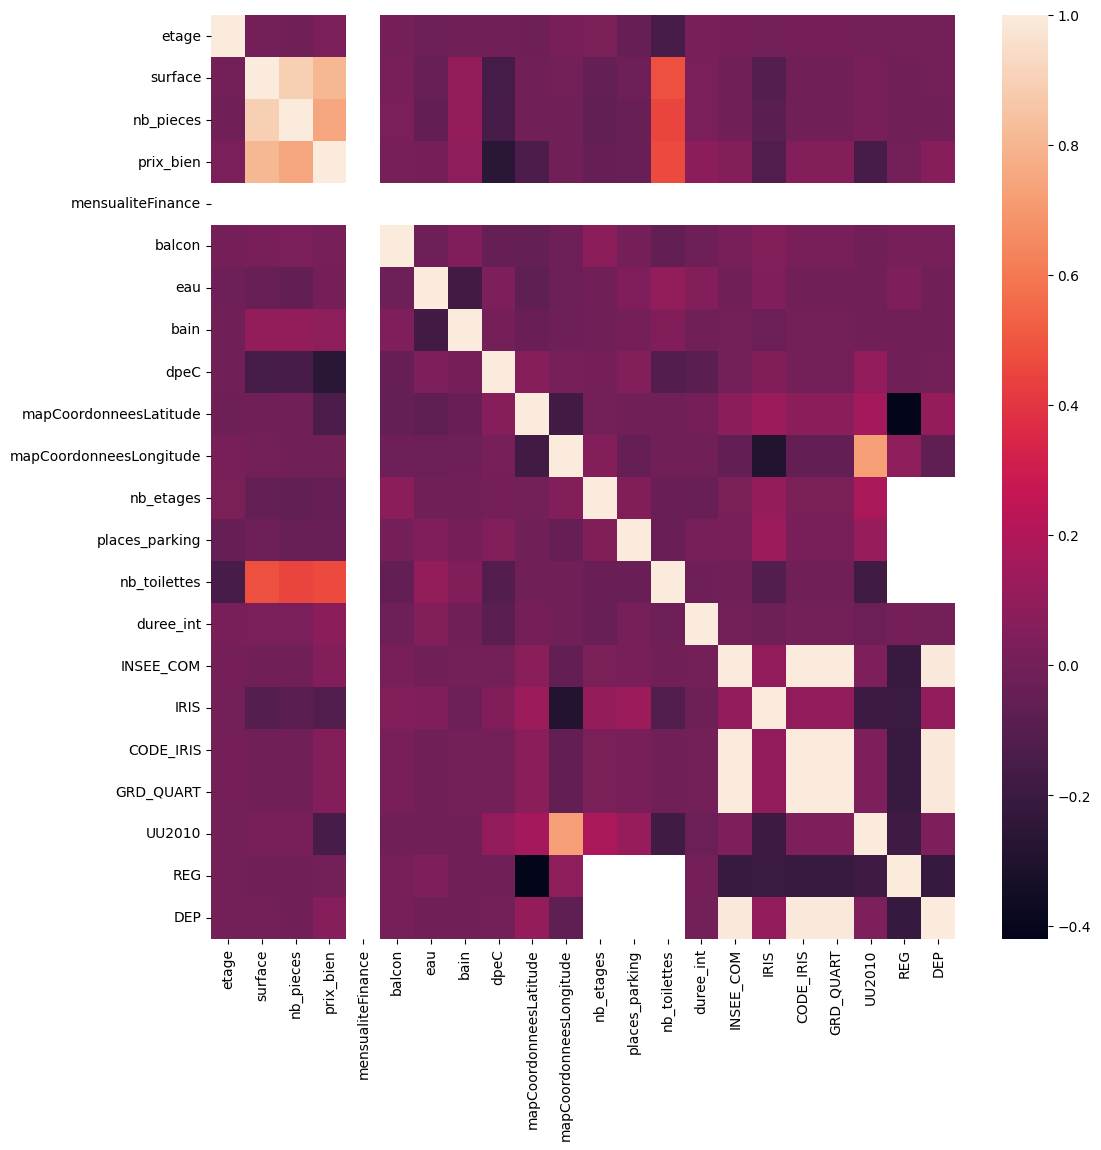

In [124]:
df_locations_quanti = df_locations_filtered.select_dtypes(exclude='object')
fig, ax = plt.subplots(figsize = (12,12))
sns.heatmap(df_locations_quanti.corr())

Cette matrice de corrélation nous incite à nous focaliser sur les variables numérique : nombre de pièces (nb_pieces) et surface.

Concernant les variables qualitatives, un test ANOVA sera à réaliser.

A priori les variables qualitatives intéressantes serait :
- type de bien (lite)
- localisation (longitude/latitude ou code commune ou code iris etc ...)
- dpe
- logement neuf

#### Premier tri de variables - ventes

Nous faisons le même exercie pour le dataframe des ventes

In [125]:
valeurs_manquantes = df_ventes.isna().sum()/df_ventes.shape[0]
valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
valeurs_manquantes_list

['prix_maison',
 'prix_terrain',
 'parking',
 'nb_terraces',
 'videophone',
 'porte_digicode',
 'surface_balcon']

In [126]:
df_ventes_filtered = df_ventes.drop(valeurs_manquantes_list, axis = 1)
df_ventes_filtered.shape

(27737, 51)

In [127]:
df_ventes_quanti = df_ventes_filtered.select_dtypes(exclude='object')
df_ventes_quanti.columns

Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'prix_bien',
       'mensualiteFinance', 'balcon', 'eau', 'bain', 'dpeC',
       'mapCoordonneesLatitude', 'mapCoordonneesLongitude', 'nb_etages',
       'places_parking', 'annee_construction', 'nb_toilettes',
       'nb_logements_copro', 'charges_copro', 'duree_int', 'INSEE_COM', 'IRIS',
       'CODE_IRIS', 'GRD_QUART', 'UU2010', 'REG', 'DEP', 'loyer_m2_median_n6',
       'nb_log_n6', 'taux_rendement_n6', 'loyer_m2_median_n7', 'nb_log_n7',
       'taux_rendement_n7', 'prix_m2_vente'],
      dtype='object')

<Axes: >

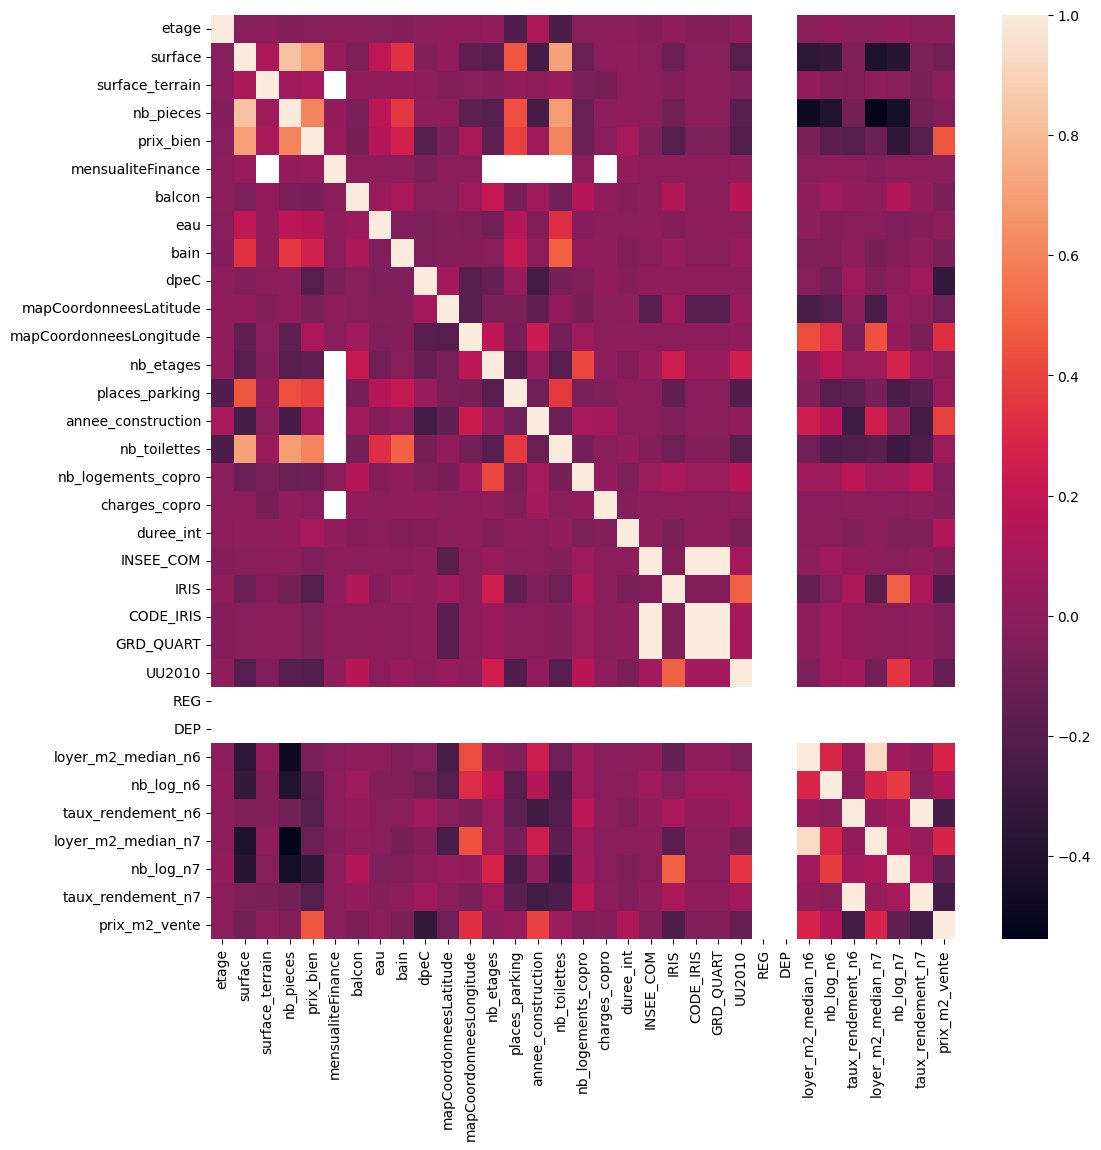

In [128]:
fig, ax = plt.subplots(figsize = (12,12))
sns.heatmap(df_ventes_quanti.corr())

là encore, cette matrice de corrélation nous incite à nous focaliser sur les variables nombre de pièves (nb_pieces) et surface

Après une prise de connaissance des contenus des fichiers csv, de la liste des colonnes, de leurs valeurs, distribution et répartition - nous avons fait le choix de nous focaliser sur les variables quantitatives suivantes :
- surface
- nb de pièces

Concernant les variables qualitatives, un test ANOVA sera à réaliser.

A priori les variables qualitatives intéressantes serait :
- type de bien (lite)
- localisation (longitude/latitude ou code commune ou code iris etc ...)
- dpe
- logement neuf

## DataViz'

#### Données de locations

##### Variable surface

<Axes: xlabel='surface'>

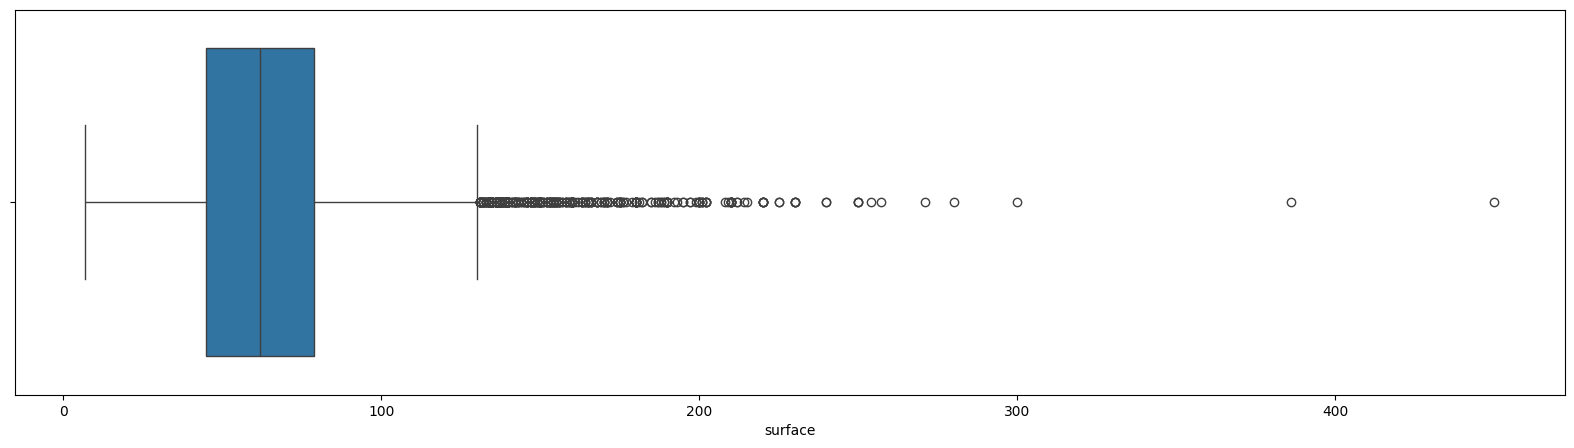

In [129]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(x=df_locations.surface)

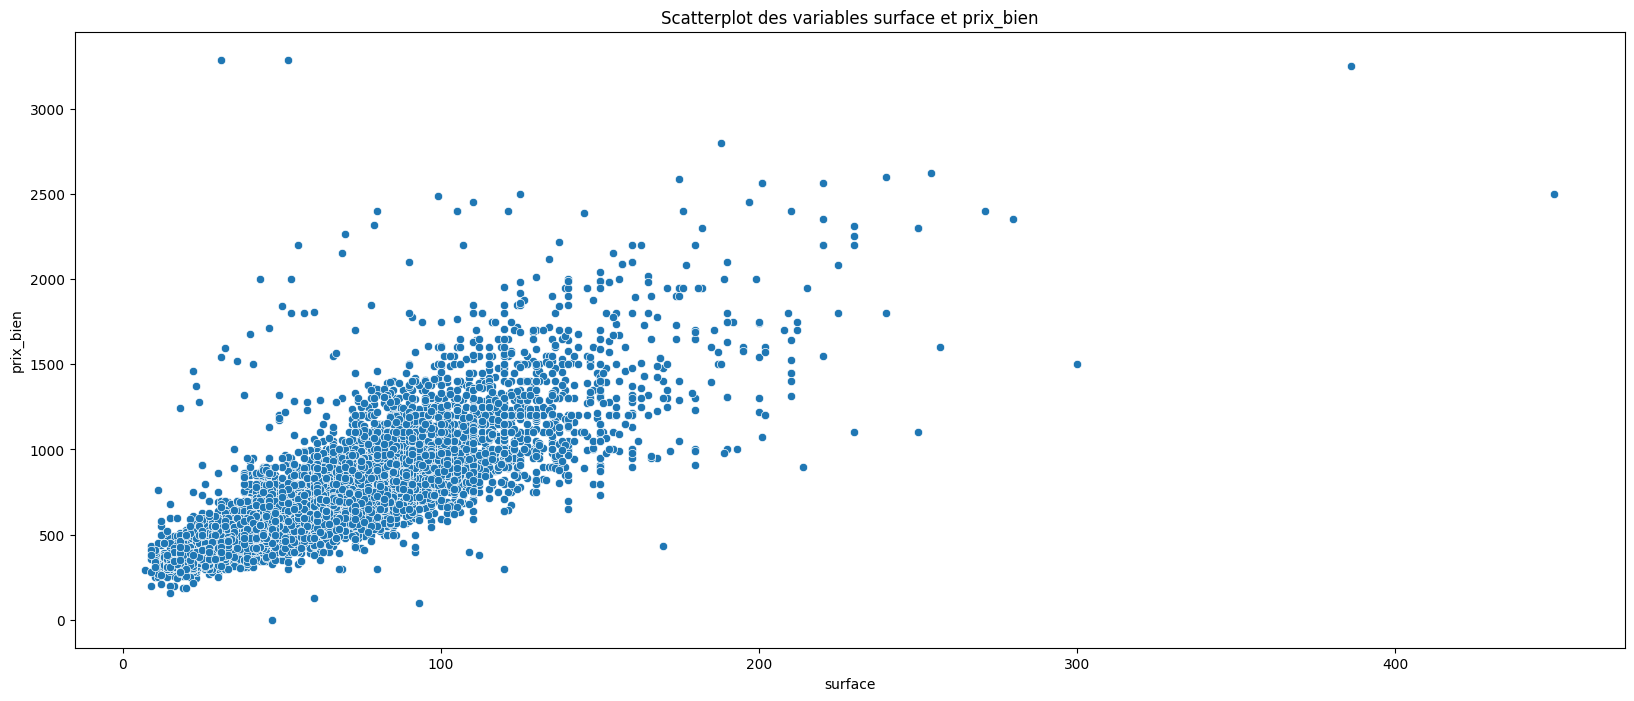

In [130]:
fig, ax = plt.subplots(figsize = (20,8))
sns.scatterplot(data=df_locations, x='surface', y='prix_bien')
plt.title('Scatterplot des variables surface et prix_bien')
plt.show()

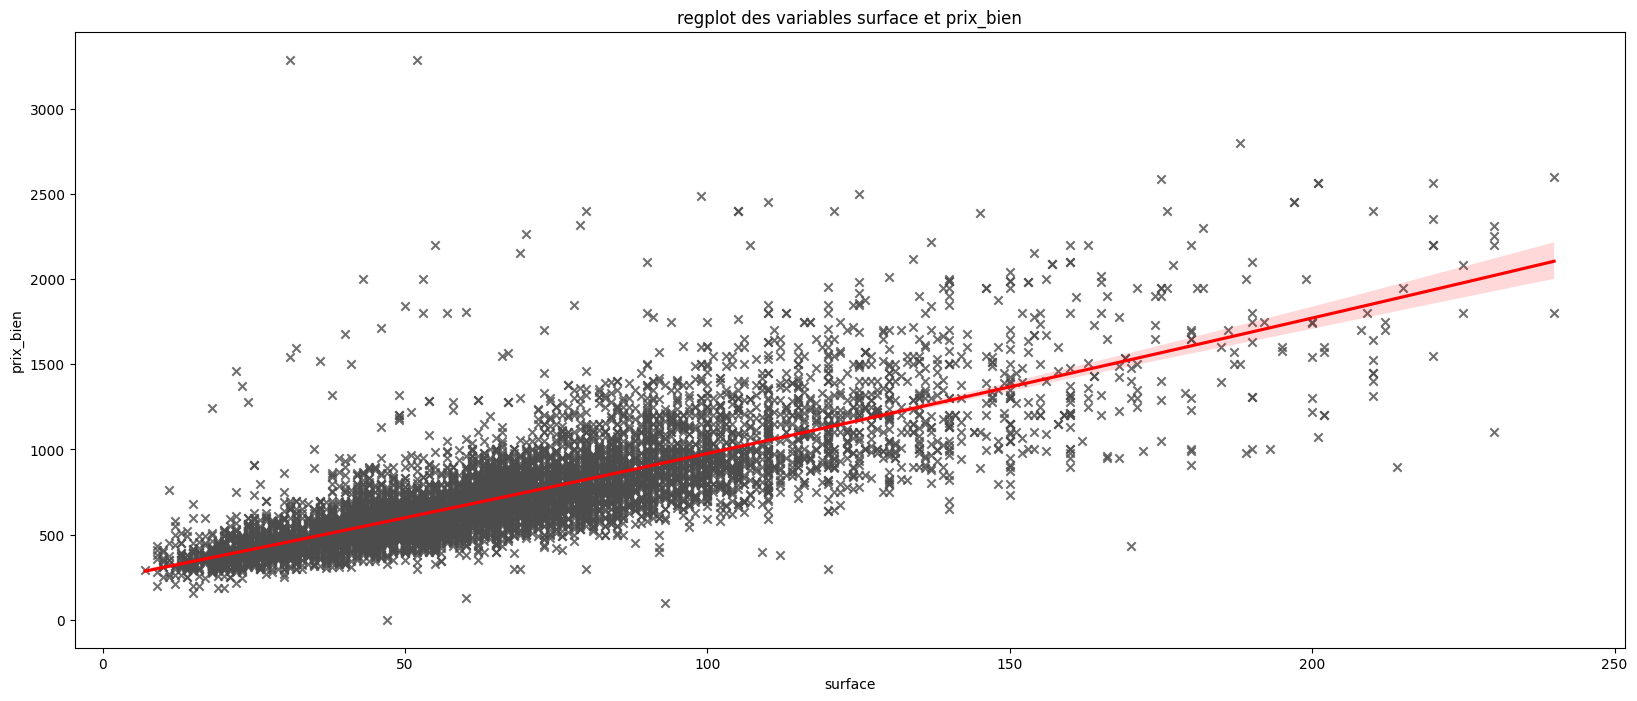

In [131]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_locations[df_locations.surface < 250], x='surface', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"))
plt.title('regplot des variables surface et prix_bien')
plt.show()

Globalement la variable surface et la variable prix_bien suivent une corrélation linéaire forte.

##### Variable nb_pieces

<Axes: xlabel='nb_pieces'>

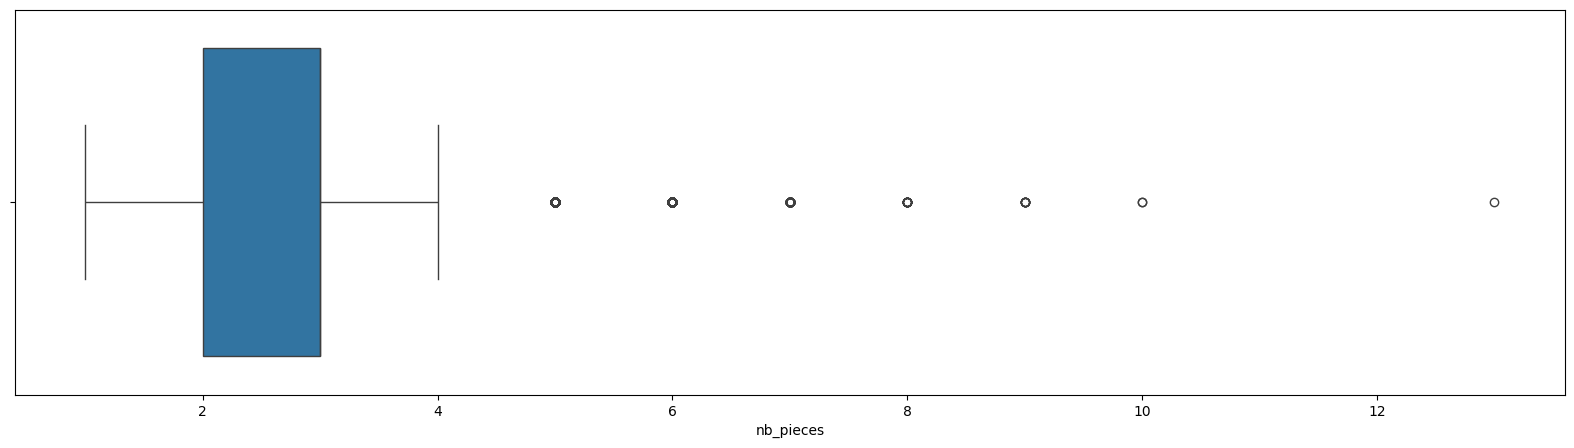

In [132]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(x=df_locations.nb_pieces)

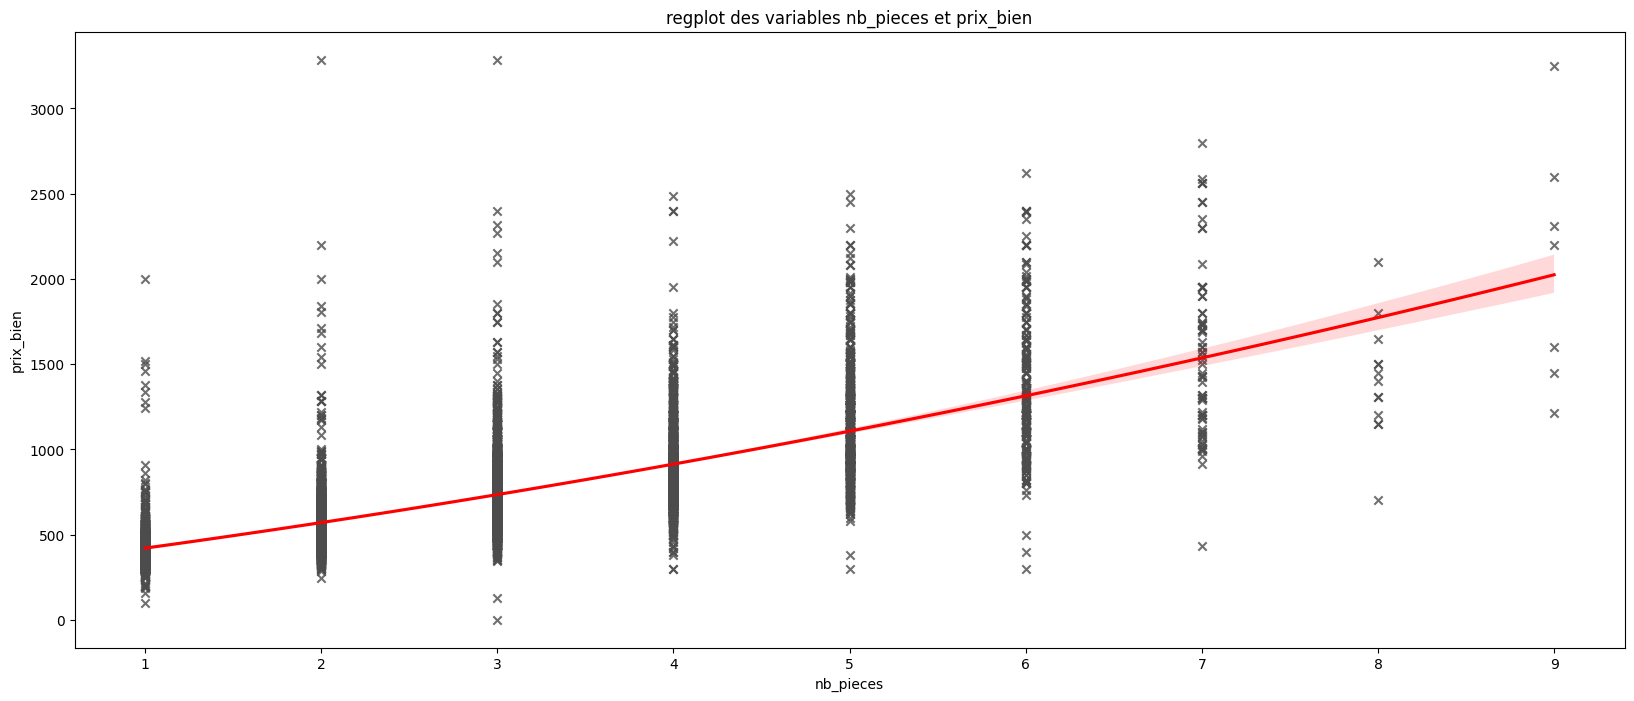

In [133]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_locations[df_locations.nb_pieces < 10], x='nb_pieces', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"))
plt.title('regplot des variables nb_pieces et prix_bien')
plt.show()

La corrélation entre nb_pieces et prix_bien n'est pas flagrante en l'état car pour chaque valeur de nb_pièces, nous avons une distribution des prix_bien assez large.

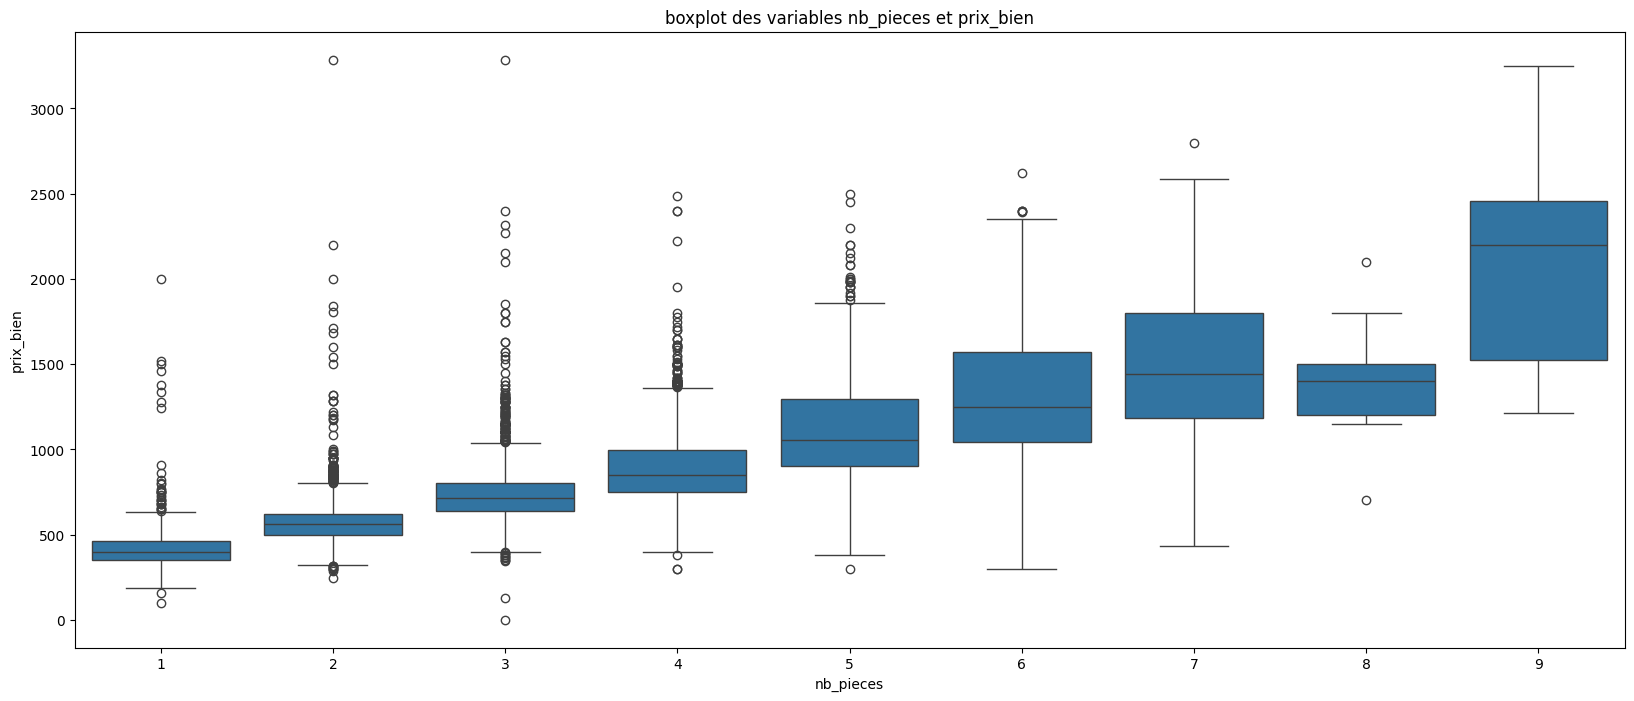

In [134]:
fig, ax = plt.subplots(figsize = (20,8))
sns.boxplot(data=df_locations[df_locations.nb_pieces < 10], x='nb_pieces', y='prix_bien')
plt.title('boxplot des variables nb_pieces et prix_bien')
plt.show()

On peut aussi considérer la variable nb_pieces comme une variable catégorielle pour faire apparaite le prix médian par nb_pieces

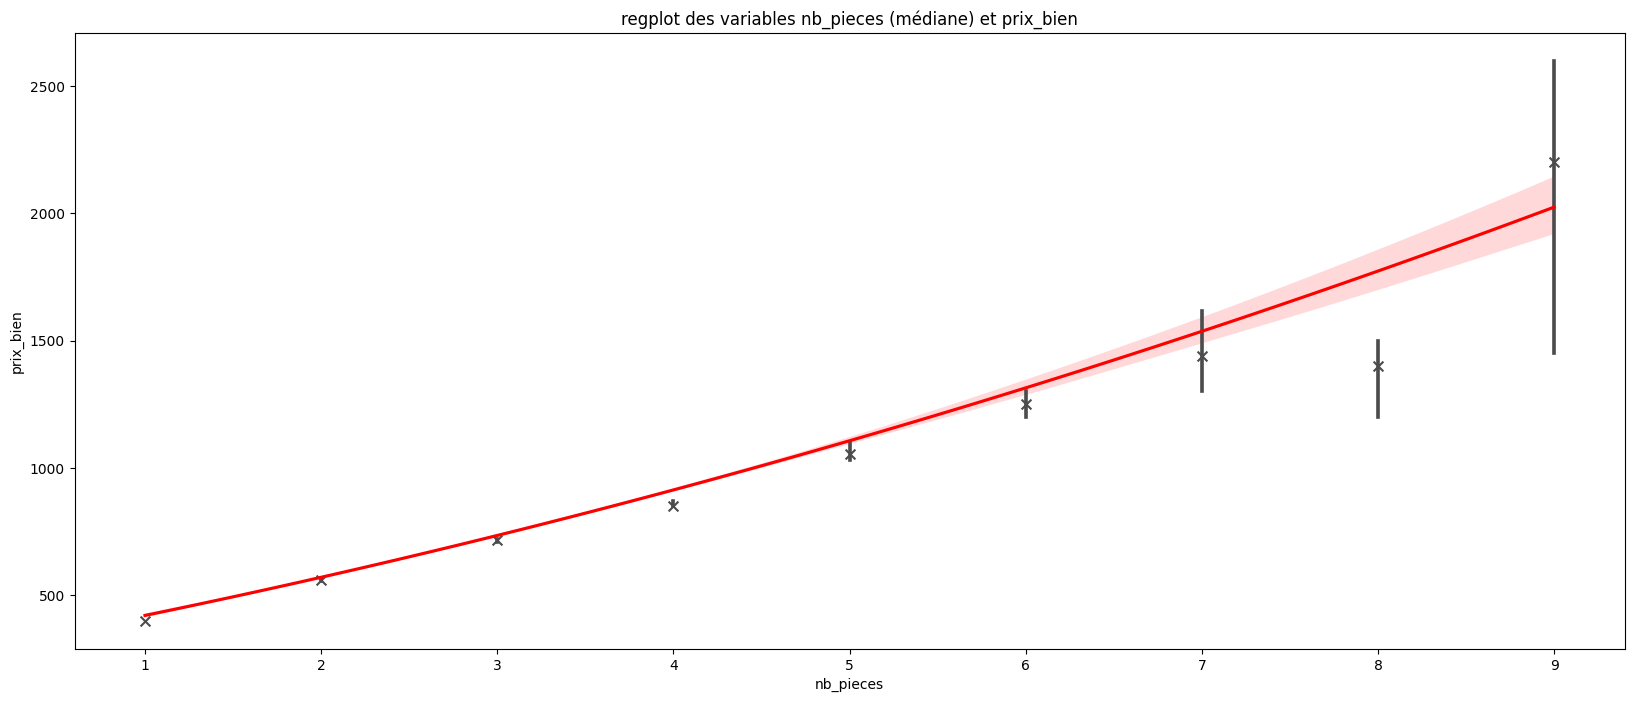

In [135]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_locations[df_locations.nb_pieces < 10], x='nb_pieces', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"), x_estimator=np.median)
plt.title('regplot des variables nb_pieces (médiane) et prix_bien')
plt.show()

Ce graphique montre que la médiane des prix de bien par nombre de pièce est très nettement corrélée au prix du bien. Surtout jusqu'à 6 pièces ou la courbe est très proche de la médiane.

In [136]:
df, feature = df_locations, "nb_pieces"

In [137]:
df[feature].value_counts()

nb_pieces
3     3911
2     3736
4     1641
1     1325
5      759
6      231
7       76
8       13
9        7
10       2
13       1
Name: count, dtype: int64

Nous faisons une vérifications sur les biens ayant un grand nombre de pièces

In [138]:
df[df[feature]>=10][['surface', 'nb_pieces', 'prix_bien', 'annee_construction']]

,surface,nb_pieces,prix_bien,annee_construction
idannonce,,,,
ag680010-369258625,450,13,2500,NaN
hektor-agfreyimmo-879,195,10,1600,1975.0
ag681106-336644436,271,10,2400,NaN


La surface et le prix du bien semblent en adéquation avec le nombre de pièces, il ne semble pas s'agit d'un erreur, nous gardond tous les enregistreme,ts

Nous regardons d'abord la répartition des biens suivant la valeur de cette variable

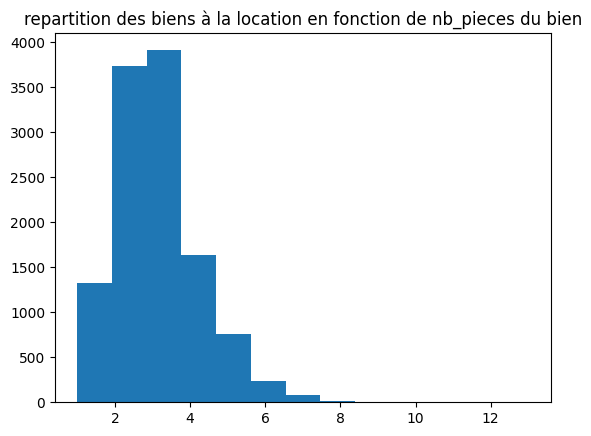

In [139]:
plt.hist(df[feature], bins =13)
plt.title (f"repartition des biens à la location en fonction de {feature} du bien");

Puis la relation entre le prix du bien et le nombre de pièces

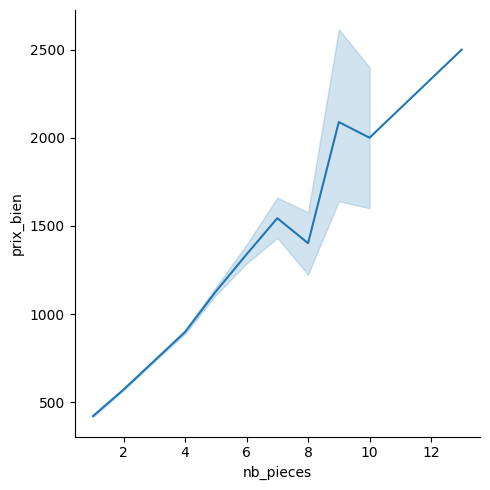

In [140]:
sns.relplot(x = feature, y = "prix_bien", data = df, kind="line")

On voit une relation quasi linéaire pour les biens de moins de 6 pièces. Les biens au dessus de 6 pièces présentent une plus grande variabilité de prix mais comme vu précédemment dans l'histogramme, ils s'appuient sur une base plus faible en terme de nombre d'enregistrements

##### Variable typedebien_lite

<Axes: xlabel='prix_bien', ylabel='typedebien_lite'>

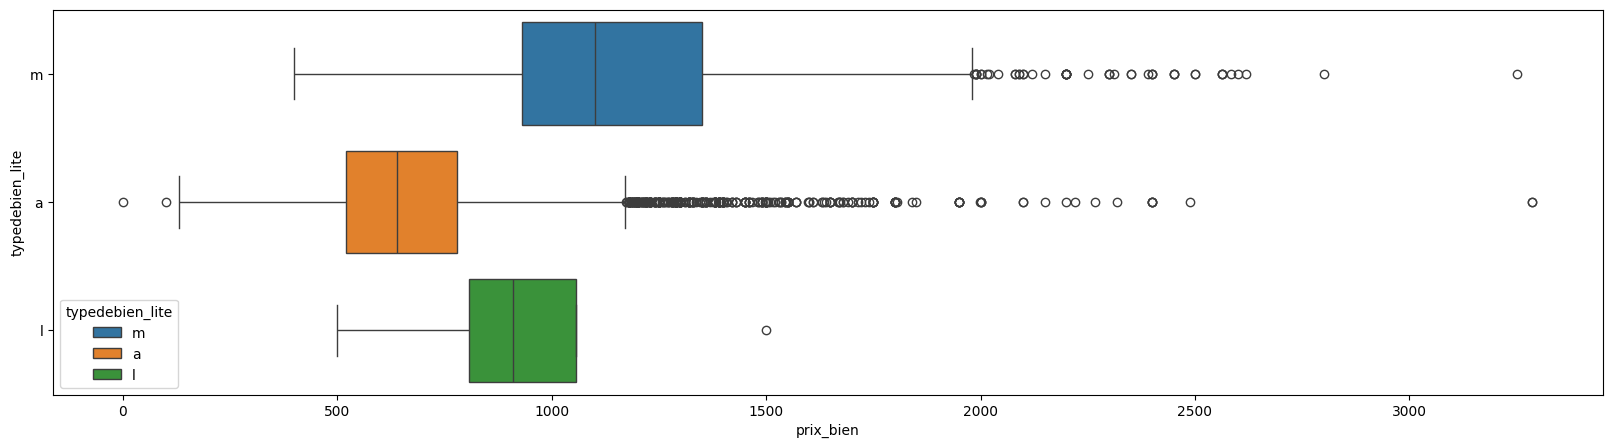

In [141]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(y='typedebien_lite', x='prix_bien', hue='typedebien_lite', data=df_locations, legend=True)

In [142]:
df_locations.typedebien_lite.value_counts()

typedebien_lite
a    10677
m     1021
l        4
Name: count, dtype: int64

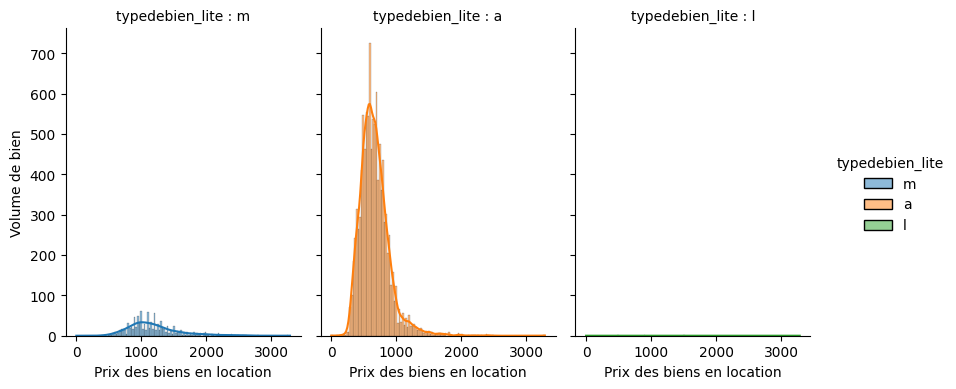

In [143]:
g = sns.displot(
    data=df_locations, 
    x="prix_bien", 
    col="typedebien_lite", 
    hue="typedebien_lite",
    kde=True, 
    height=4, 
    aspect=.7,
)
g.set_axis_labels("Prix des biens en location", "Volume de bien")
g.set_titles("typedebien_lite : {col_name}")

Nous pouvons très certainement ignorer les lots (l) dans notre analyse car le volume de biens en locations est très faible.

Par contre nous avons une distribution des prix différentes entre typedebien_lite : a et typedebien_lite : m.

La distribution nous indique que les maisons sont plus chères que les appartements.

##### Variable logement_neuf

<Axes: xlabel='prix_bien', ylabel='logement_neuf'>

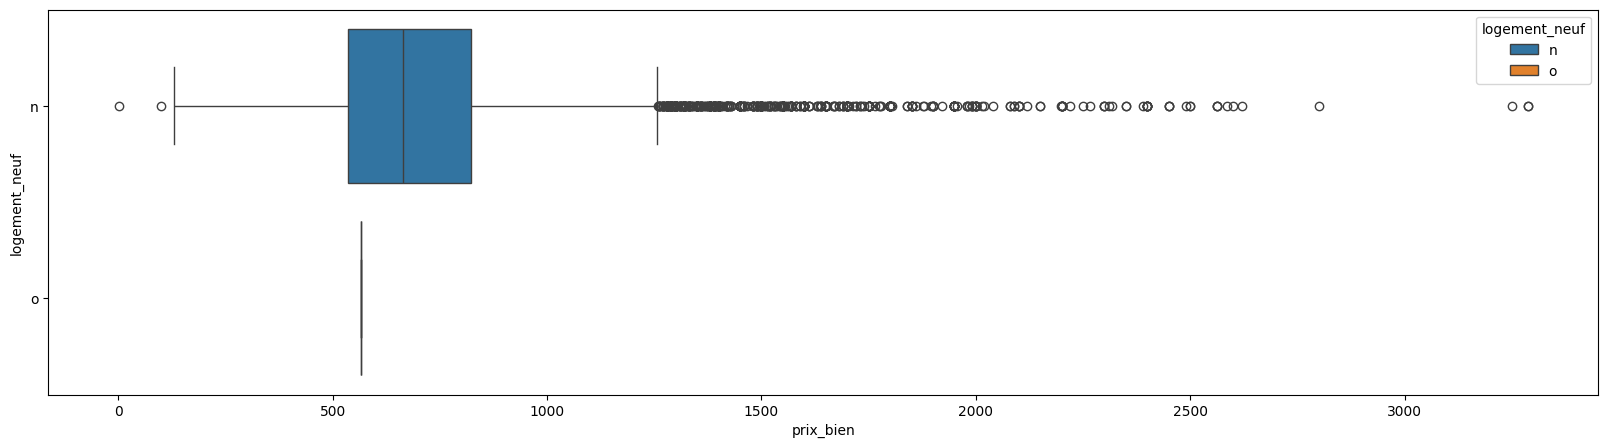

In [144]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(y='logement_neuf', x='prix_bien', hue='logement_neuf', data=df_locations, legend=True)

In [145]:
df_locations.logement_neuf.value_counts()

logement_neuf
n    11339
o        1
Name: count, dtype: int64

Pour les locations, la variable logement_neuf n'est pas pertinente car nous avons la même modalité pour tout les échantillons sauf 1.

##### Variable dpeL

<Axes: xlabel='prix_bien', ylabel='dpeL'>

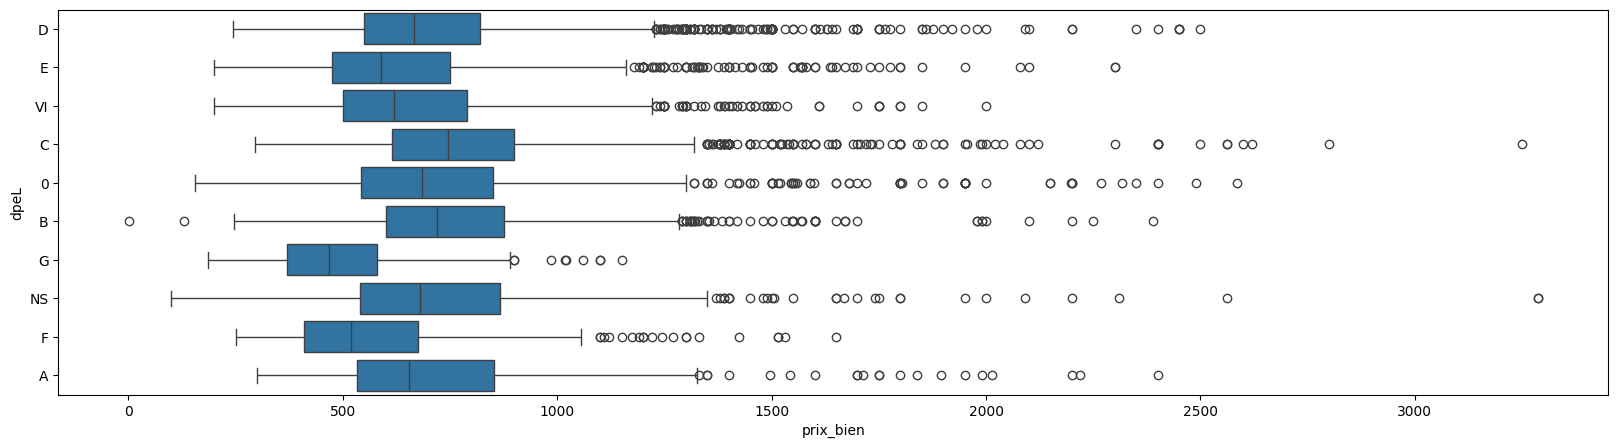

In [146]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(data=df_locations, y='dpeL', x='prix_bien')

In [147]:
df_locations.dpeL.value_counts()

dpeL
D     2894
E     2102
C     1932
VI    1180
0     1139
B      988
F      565
NS     486
A      260
G      156
Name: count, dtype: int64

Le boxplot nous indique que les modalité F et G ont des prix bien plus faible que les autres modalités.

Un One-Hot Encoding en ne gardant que les colonnes F et G pourrait aider à la bonne prédiction du modèle sur les prix faibles.

##### Variable INSEE_COM

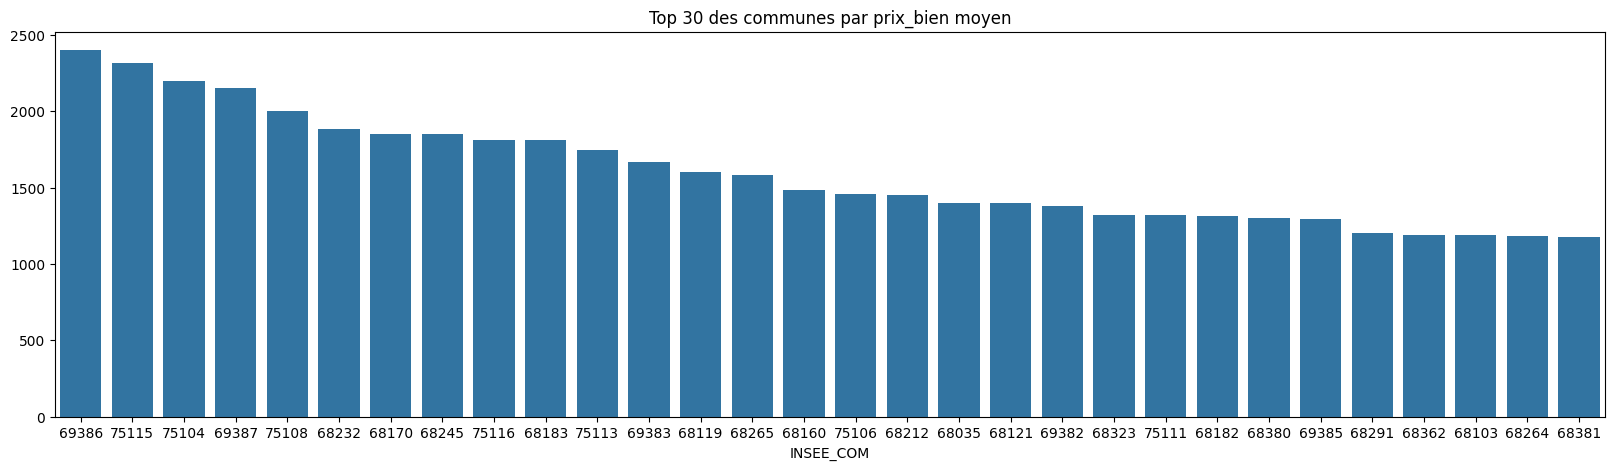

In [148]:
fig, ax = plt.subplots(figsize = (20,5))
group_commune = df_locations.groupby('INSEE_COM')['prix_bien'].mean().sort_values(ascending=False)[:30]

sns.barplot(x=group_commune.index, y=group_commune.values, order=group_commune.index)
plt.title('Top 30 des communes par prix_bien moyen');

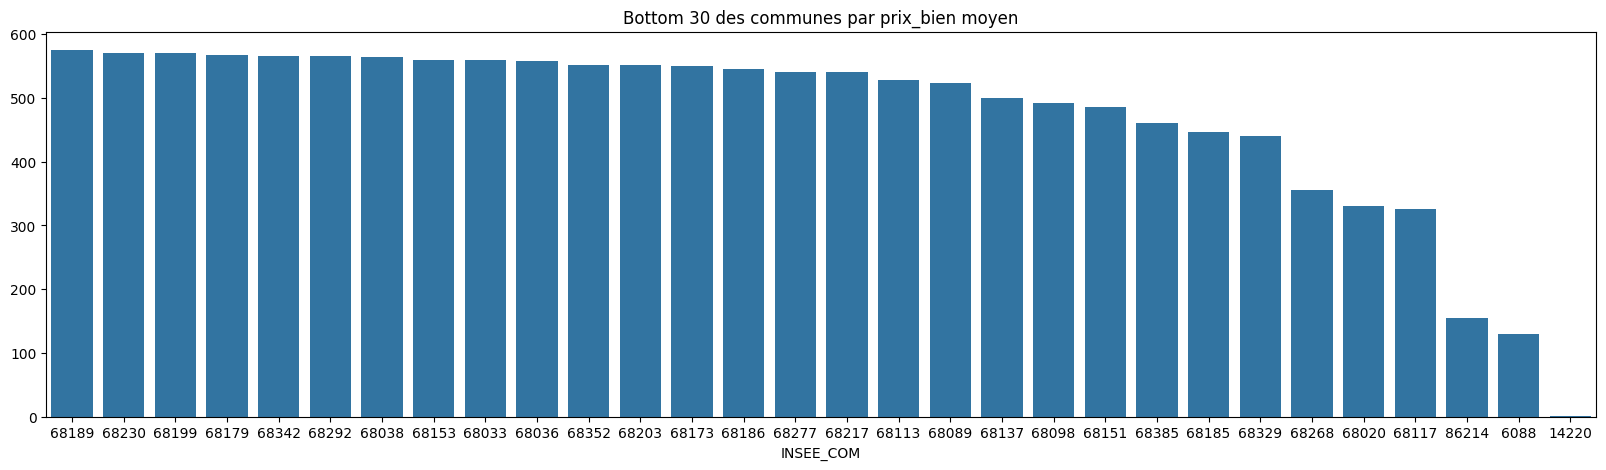

In [149]:
fig, ax = plt.subplots(figsize = (20,5))
group_commune = df_locations.groupby('INSEE_COM')['prix_bien'].mean().sort_values(ascending=False)[-30:]

sns.barplot(x=group_commune.index, y=group_commune.values, order=group_commune.index)
plt.title('Bottom 30 des communes par prix_bien moyen');

La variable INSEE_COM influe sur le prix du bien mais il y a trop de modalités.

Nous devons trouver un moyen de regouper les communes entres elles.

#### Données de ventes

##### Variable surface

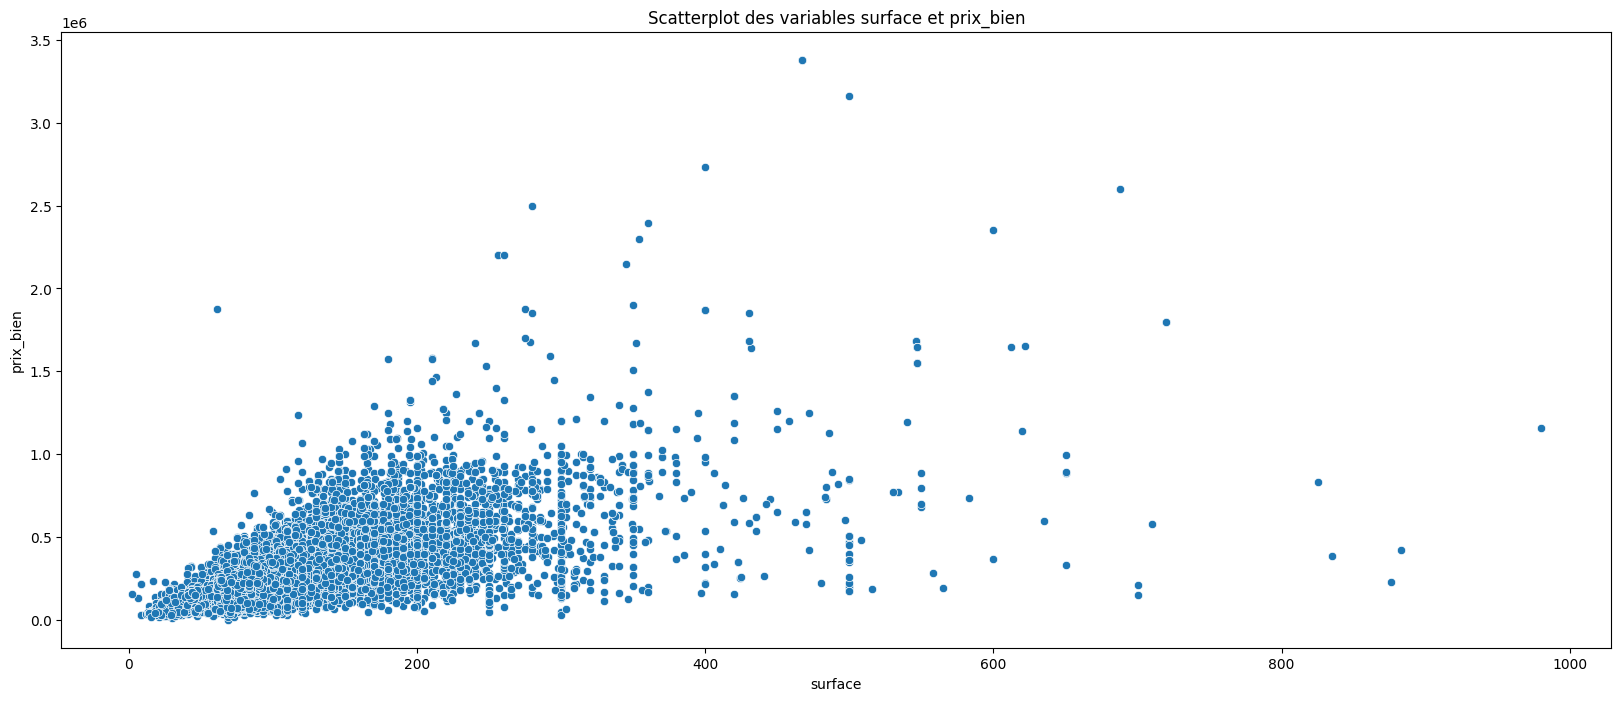

In [150]:
fig, ax = plt.subplots(figsize = (20,8))
sns.scatterplot(data=df_ventes, x='surface', y='prix_bien')
plt.title('Scatterplot des variables surface et prix_bien')
plt.show()

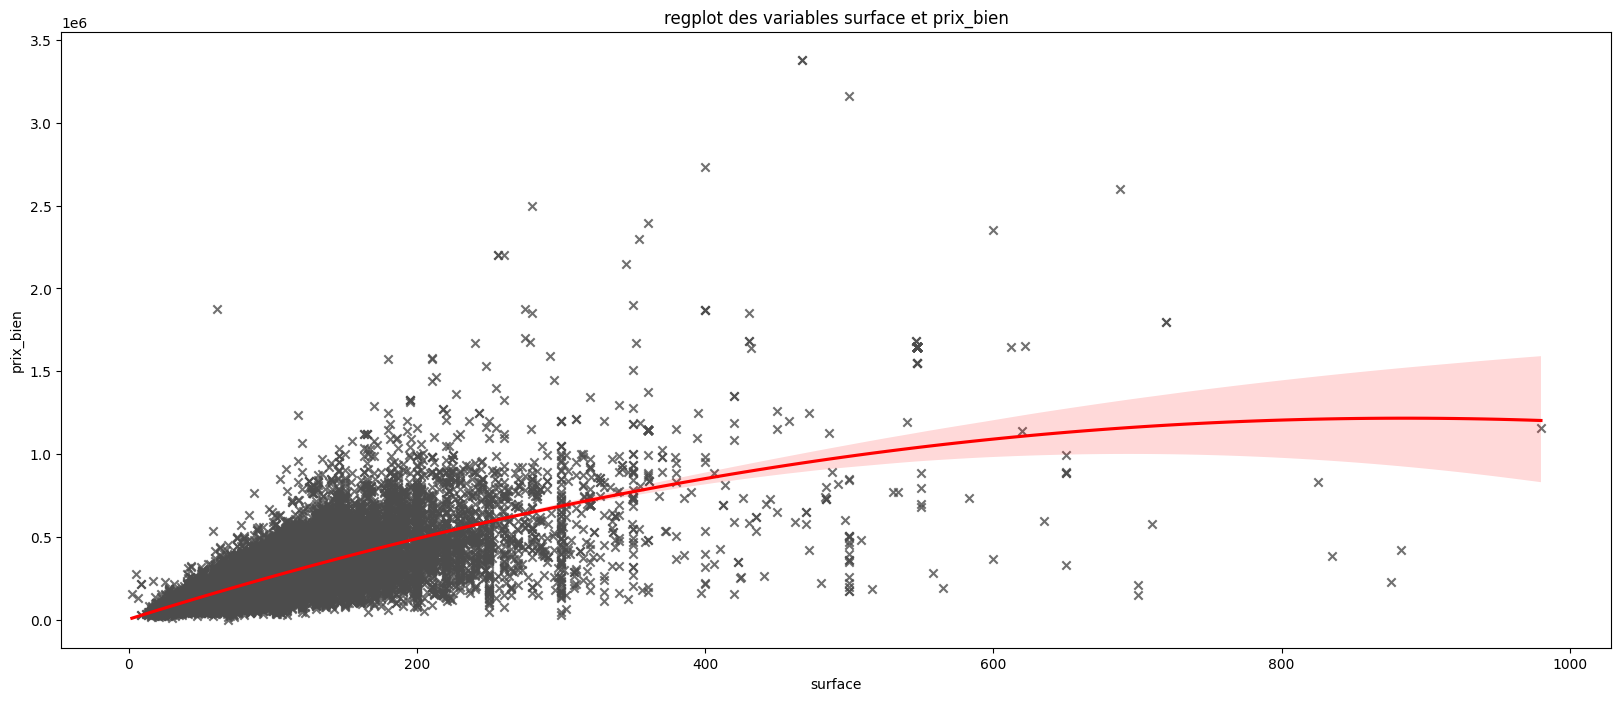

In [151]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_ventes, x='surface', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"))
plt.title('regplot des variables surface et prix_bien')
plt.show()

Contrairement aux locations, pour les ventes - la corrélation entre surface et prix_bien est présente mais moins forte. Nous avons plus de données et des distributions bien plus large.

<Axes: xlabel='surface'>

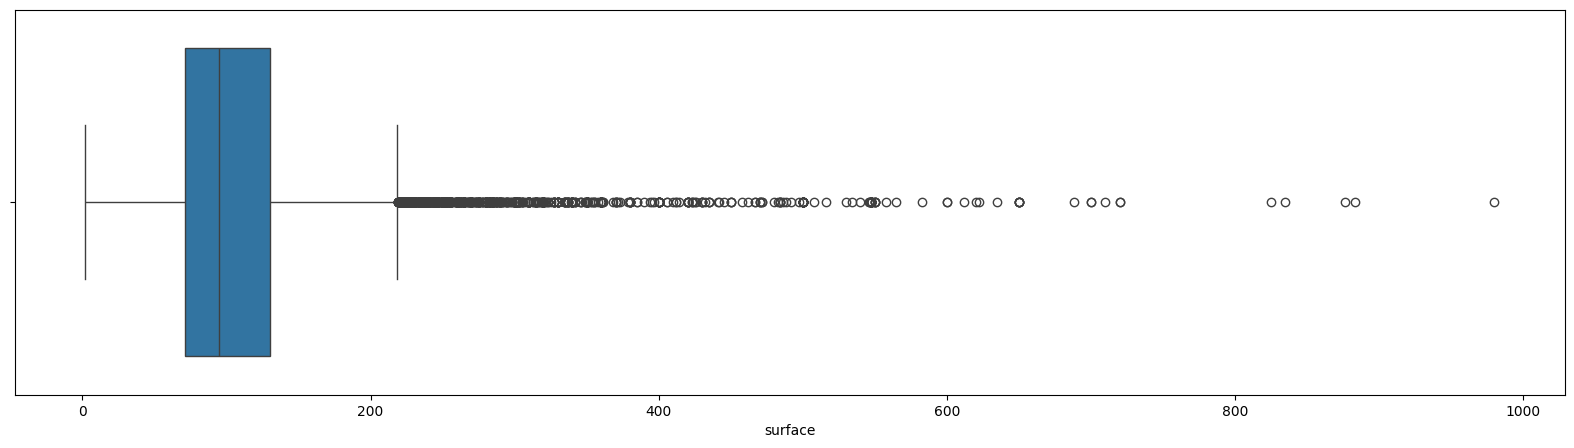

In [152]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(x=df_ventes.surface)

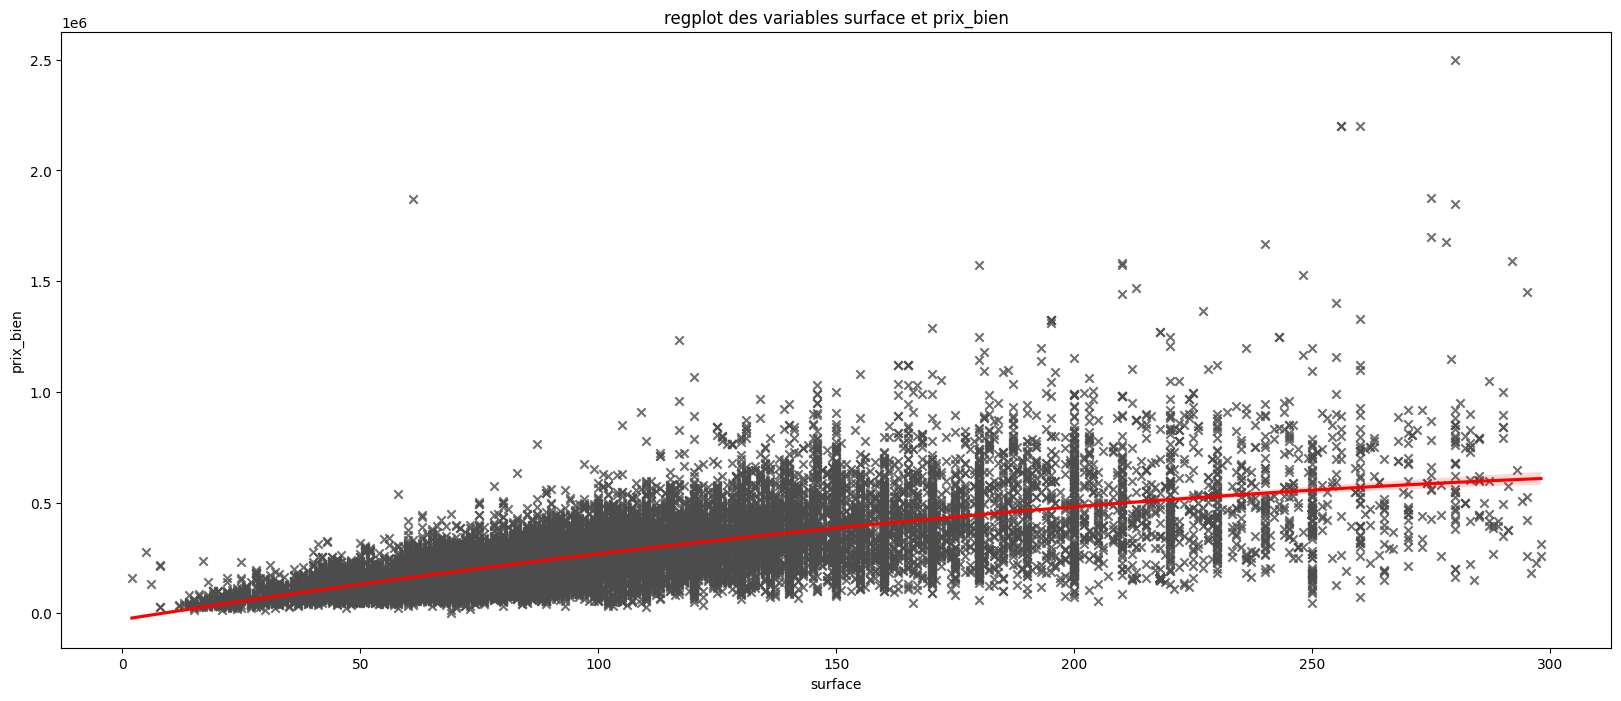

In [153]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_ventes[df_ventes['surface'] < 300], x='surface', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"))
plt.title('regplot des variables surface et prix_bien')
plt.show()

Si on ignore les valeur extrèment hautes, alors la corrélation est bien plus nette.

##### Variable nb_pieces

<Axes: xlabel='nb_pieces'>

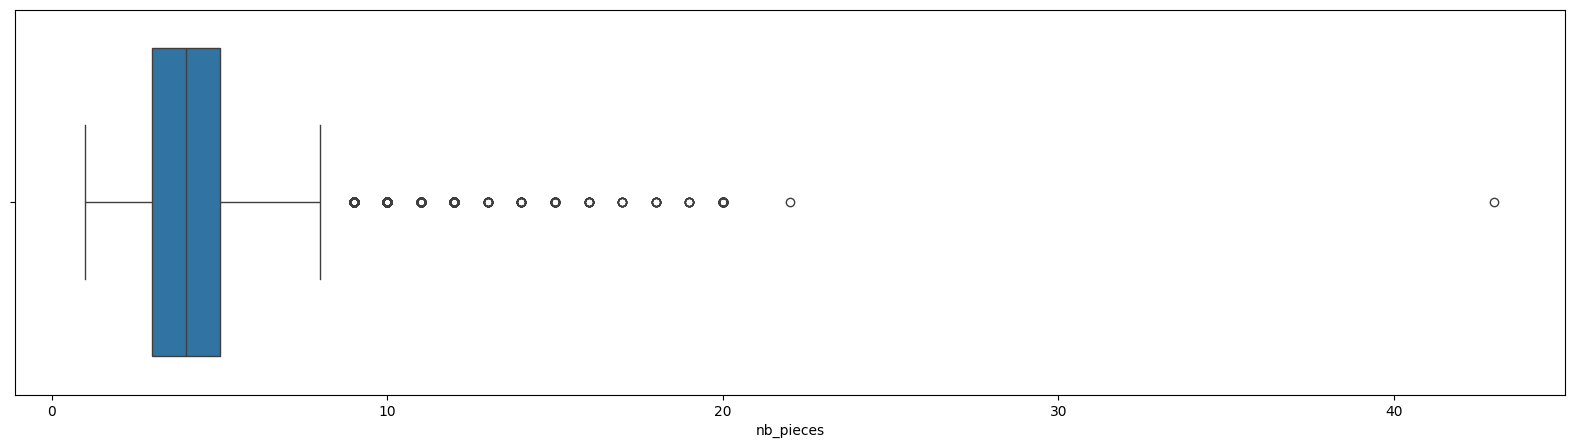

In [154]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(x=df_ventes.nb_pieces)

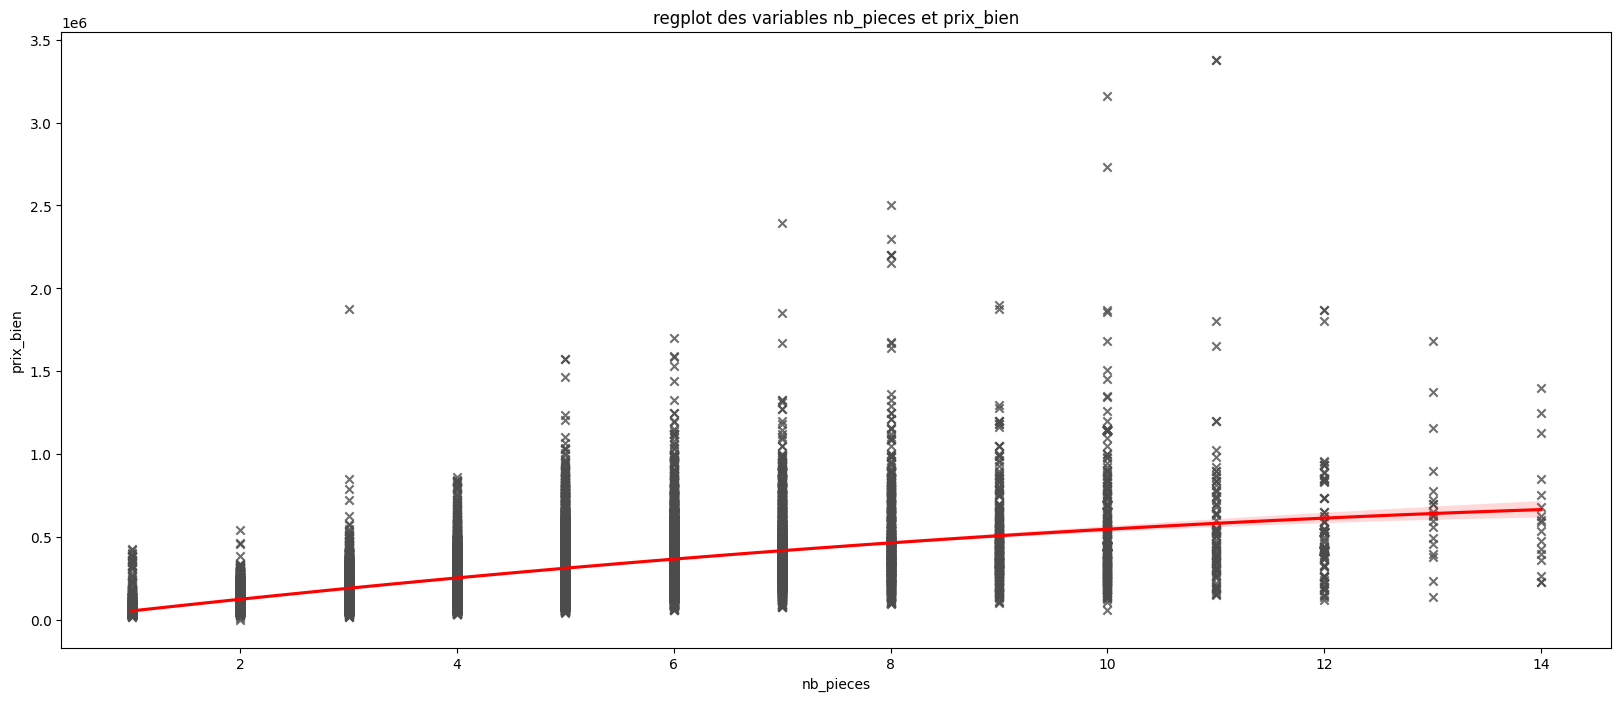

In [155]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_ventes[df_ventes['nb_pieces'] < 15], x='nb_pieces', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"))
plt.title('regplot des variables nb_pieces et prix_bien')
plt.show()

La corrélation entre nb_pieces et prix_bien n'est pas flagrante en l'état car pour chaque valeur de nb_pièces, nous avons une distribution des prix_bien assez large.

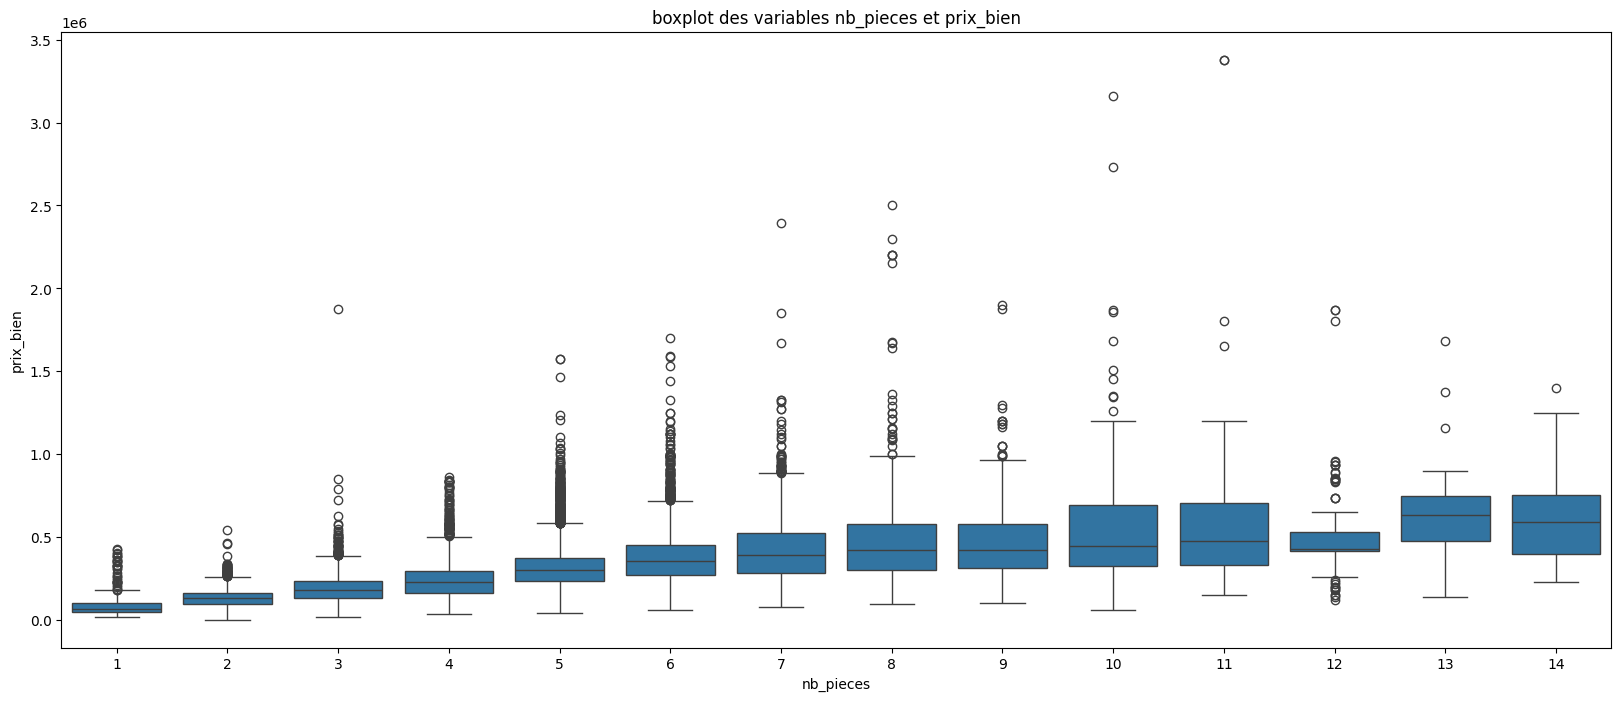

In [156]:
fig, ax = plt.subplots(figsize = (20,8))
sns.boxplot(data=df_ventes[df_ventes['nb_pieces'] < 15], x='nb_pieces', y='prix_bien')
plt.title('boxplot des variables nb_pieces et prix_bien')
plt.show()

On peut aussi considérer la variable nb_pieces comme une variable catégorielle pour faire apparaite le prix médian par nb_pieces

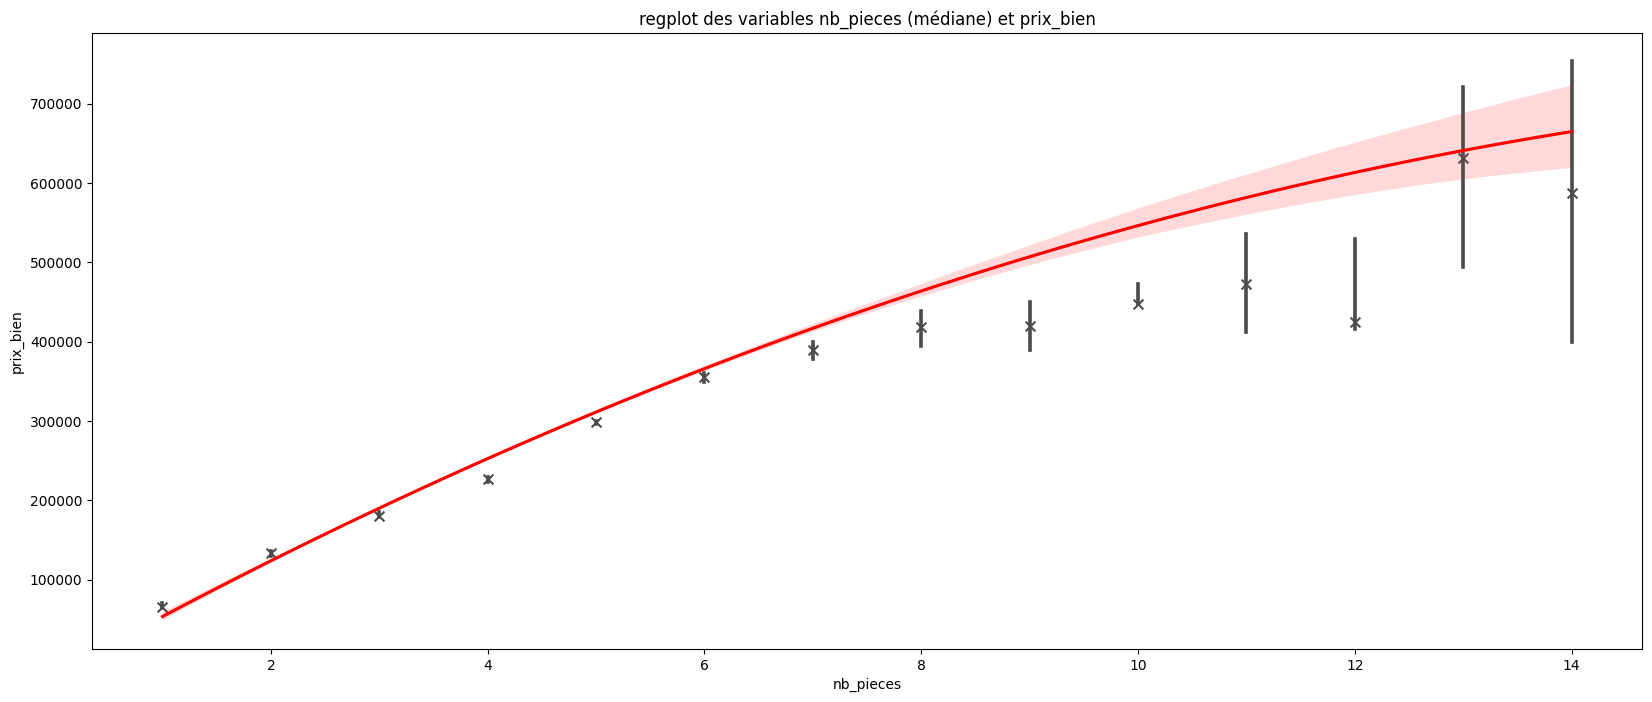

In [157]:
fig, ax = plt.subplots(figsize = (20,8))
sns.regplot(data=df_ventes[df_ventes['nb_pieces'] < 15], x='nb_pieces', y='prix_bien', order = 2, marker="x", color=".3", line_kws=dict(color="r"), x_estimator=np.median)
plt.title('regplot des variables nb_pieces (médiane) et prix_bien')
plt.show()

Ce graphique montre que la médiane des prix de bien par nombre de pièce est très nettement corrélée au prix du bien. Surtout jusqu'à 6 pièces ou la courbe est très droite.

In [158]:
df, feature = df_ventes, "nb_pieces"

In [159]:
df[feature].value_counts().sort_index()

nb_pieces
1      542
2     2957
3     5141
4     5849
5     6922
6     3222
7     1438
8      706
9      296
10     309
11      92
12     121
13      19
14      17
15      31
16      10
17       6
18       7
19       6
20      44
22       1
43       1
Name: count, dtype: int64

Nous faisons une vérifications sur les biens ayant un grand nombre de pièces

In [160]:
df[df[feature]>=20][['surface', 'nb_pieces', 'prix_bien', 'annee_construction']]

,surface,nb_pieces,prix_bien,annee_construction
idannonce,,,,
ag671791-380740432,547,20,1548000,NaN
ag671791-382213339,547,20,1548000,NaN
ag671791-381510118,547,20,1548000,NaN
ag671791-382959368,547,20,1548000,NaN
ag671791-377792077,547,20,1648000,NaN
ag671791-379287550,547,20,1648000,NaN
hektor-ethiqu-9269,700,20,210000,NaN
ag671791-375567559,547,20,1648000,NaN
ag671791-374824372,547,20,1648000,NaN


En voyant la surface et le prix, il semblerait que plusieurs annonces référencent le même bien. On pourra par la suite filtrer les boens uniques sur ces 3 critères pour supprimer les doublons.
Vue sa surface (et éventuellement son prix), le bien ayant 43 pièces semble être une erreur, nous ne le considérerons pas par la suite

In [161]:
df = df[df[feature] <43]

Nous regardons d'abord la répartition des biens suivant la valeur de cette variable

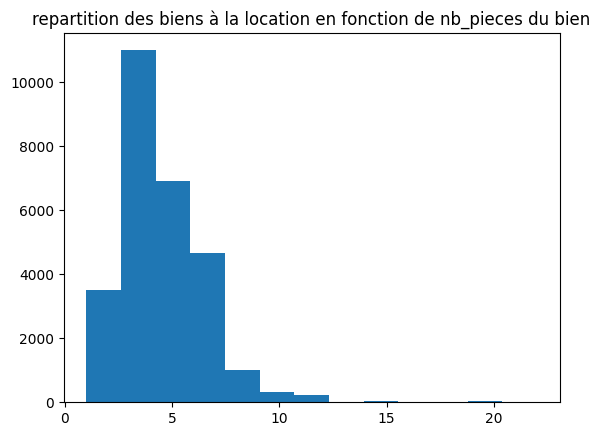

In [162]:
plt.hist(df[feature], bins =13)
plt.title (f"repartition des biens à la location en fonction de {feature} du bien");

Puis la relation entre le prix du bien et le nombre de pièces

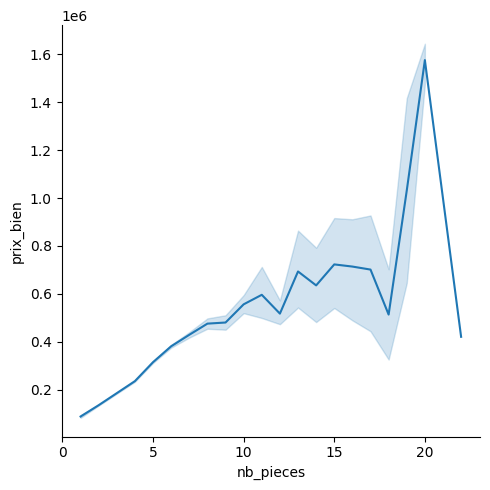

In [163]:
sns.relplot(x = feature, y = "prix_bien", data = df, kind="line")

On voit une relation quais linéaire pour les biens de moins de 10 pièces. Les biens au dessu de 10 pièces présentent une plus grande variabilité de prix mais comme vu précédemment dans l'histogramme, ils s'appuient sur une base plus faible en terme de nombre d'enregistrements.
Le bien de 22 pièces a une surface en adéquation avec le nombre de pièces mais son prix ne suit pas du tout la tendance générale. On pourra l'enlever par la suite car c'est un outlier qui doit comporter des spécificités particulières (état du bien?) et étant le seul bien de cette surface et ce nombre de pièce, il ne pourra pas apporter d'information utile à notre modèle

##### Variable typedebien_lite

<Axes: xlabel='prix_bien', ylabel='typedebien_lite'>

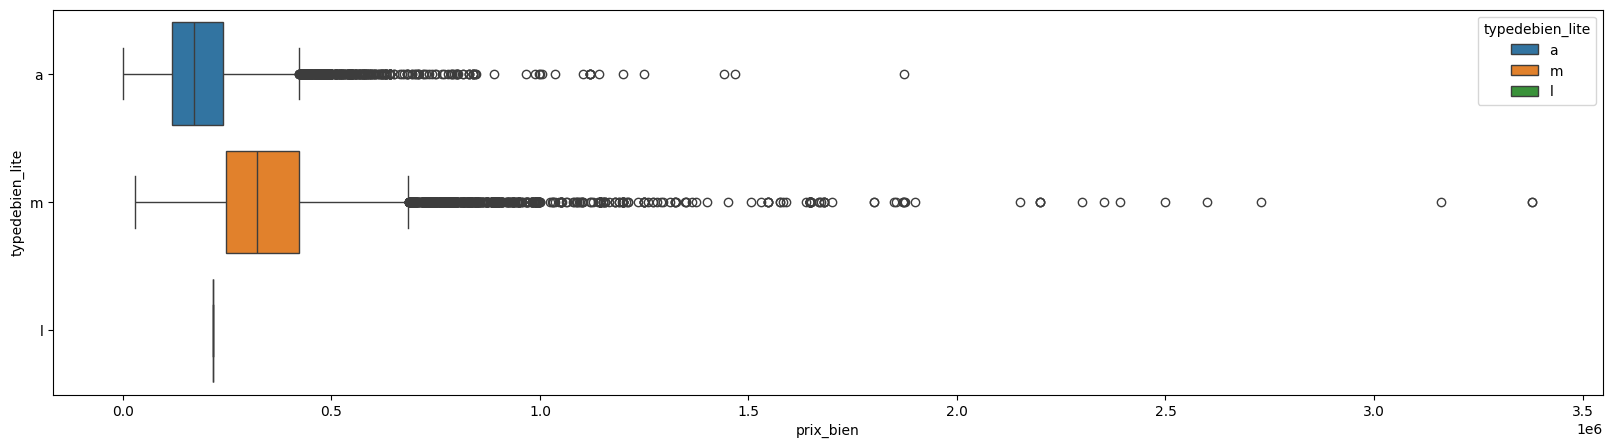

In [164]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(y='typedebien_lite', x='prix_bien', hue='typedebien_lite', data=df_ventes, legend=True)

In [165]:
df_ventes.typedebien_lite.value_counts()

typedebien_lite
m    13938
a    13798
l        1
Name: count, dtype: int64

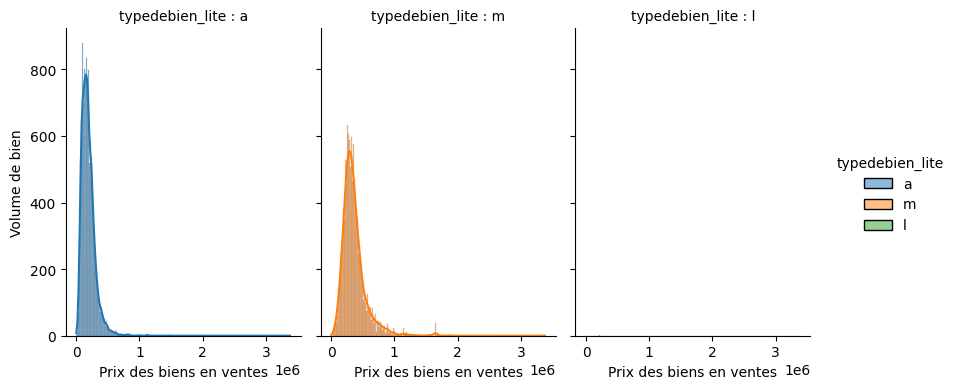

In [166]:
g = sns.displot(
    data=df_ventes, 
    x="prix_bien", 
    col="typedebien_lite", 
    hue="typedebien_lite",
    kde=True, 
    height=4, 
    aspect=.7,
)
g.set_axis_labels("Prix des biens en ventes", "Volume de bien")
g.set_titles("typedebien_lite : {col_name}")

De la même façon que pour les locations, nous pouvons très certainement ignorer les lots (l) dans notre analyse car le volume de biens en locations est très faible.

Par contre nous avons une distribution des prix différentes entre typedebien_lite : a et typedebien_lite : m.

La distribution nous indique que les maisons sont plus chères que les appartements.

##### Variable logement_neuf

<Axes: xlabel='prix_bien', ylabel='logement_neuf'>

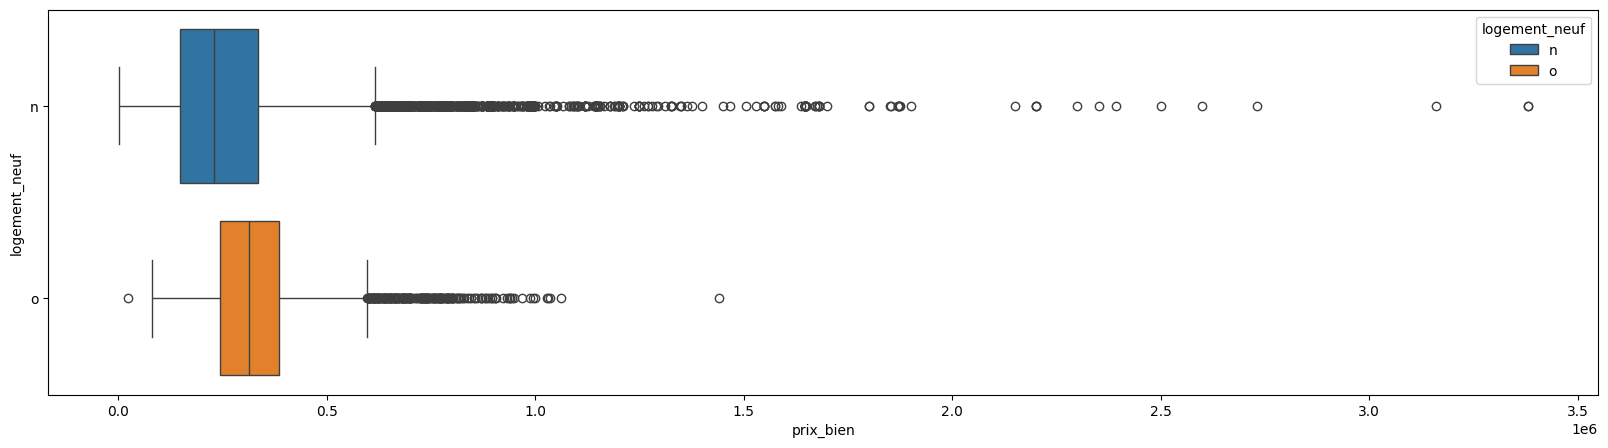

In [167]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(y='logement_neuf', x='prix_bien', hue='logement_neuf', data=df_ventes, legend=True)

In [168]:
df_ventes.logement_neuf.value_counts()

logement_neuf
n    23391
o     3607
Name: count, dtype: int64

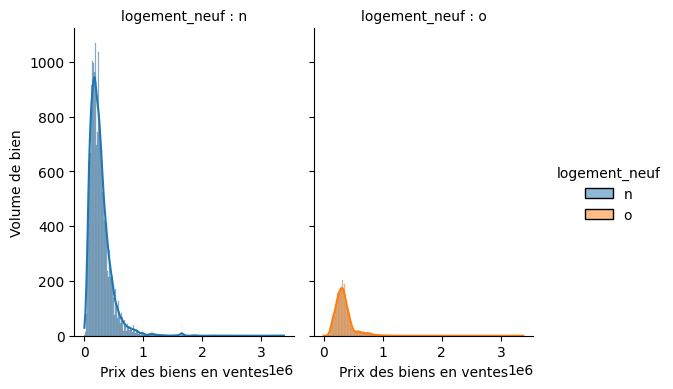

In [169]:
g = sns.displot(
    data=df_ventes, 
    x="prix_bien", 
    col="logement_neuf", 
    hue="logement_neuf",
    kde=True, 
    height=4, 
    aspect=.7,
)
g.set_axis_labels("Prix des biens en ventes", "Volume de bien")
g.set_titles("logement_neuf : {col_name}")

Pour les biens en ventes, nous avons cette fois les logements neufs. 

Les graphiques montrent qu'un logement neuf (o) est plus chère. Cela marque l'importance de cette variable dans la prédiction du prix du bien.

##### Variable dpeL

<Axes: xlabel='prix_bien', ylabel='dpeL'>

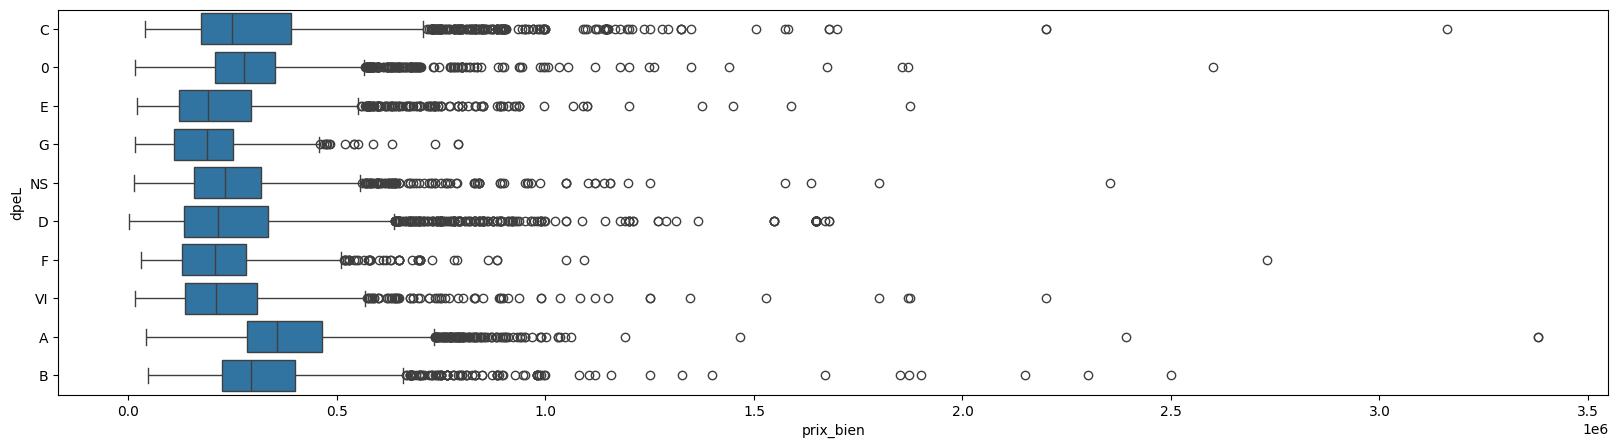

In [170]:
fig, ax = plt.subplots(figsize = (20,5))
sns.boxplot(data=df_ventes, y='dpeL', x='prix_bien')

In [171]:
df_ventes.dpeL.value_counts()

dpeL
D     6011
0     4766
C     4012
E     3999
NS    2399
VI    1660
B     1575
F     1481
A     1327
G      507
Name: count, dtype: int64

Concernant les ventes, le boxplot de la variable dpeL nous indique autre chose.

Il nous indique que les modalité A et B ont des prix bien plus élevés que les autres modalités.

Un One-Hot Encoding en ne gardant que les colonnes A et V pourrait aider à la bonne prédiction du modèle sur les prix élevés.

##### Variable INSEE_COM

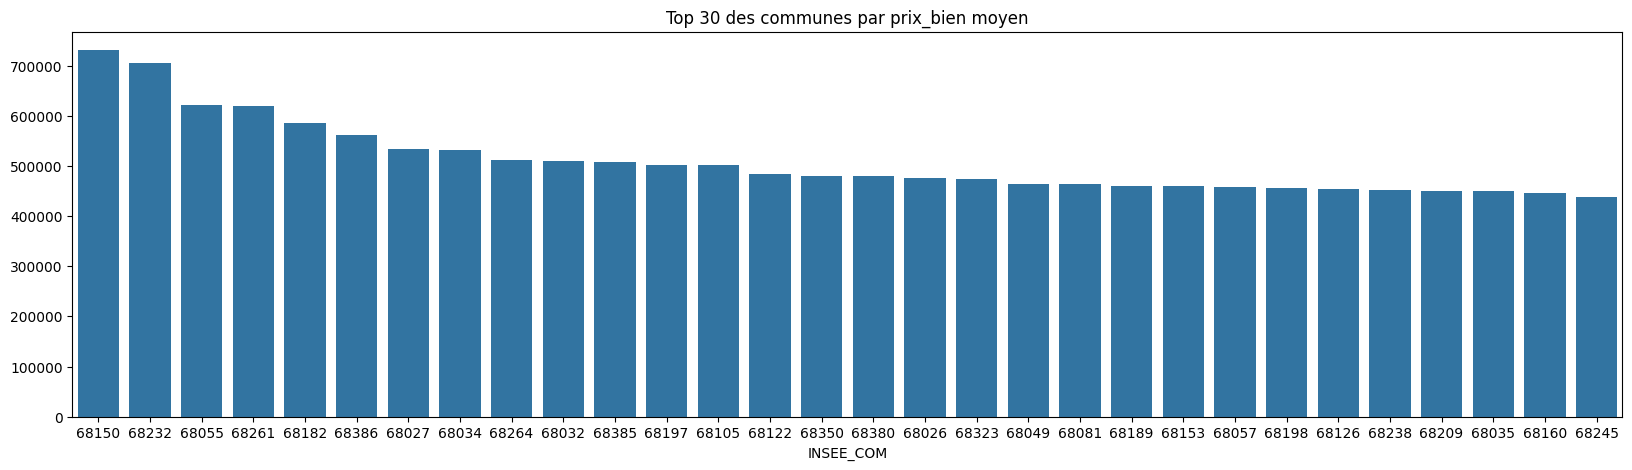

In [172]:
fig, ax = plt.subplots(figsize = (20,5))
group_commune = df_ventes.groupby('INSEE_COM')['prix_bien'].mean().sort_values(ascending=False)[:30]

sns.barplot(x=group_commune.index, y=group_commune.values, order=group_commune.index)
plt.title('Top 30 des communes par prix_bien moyen');

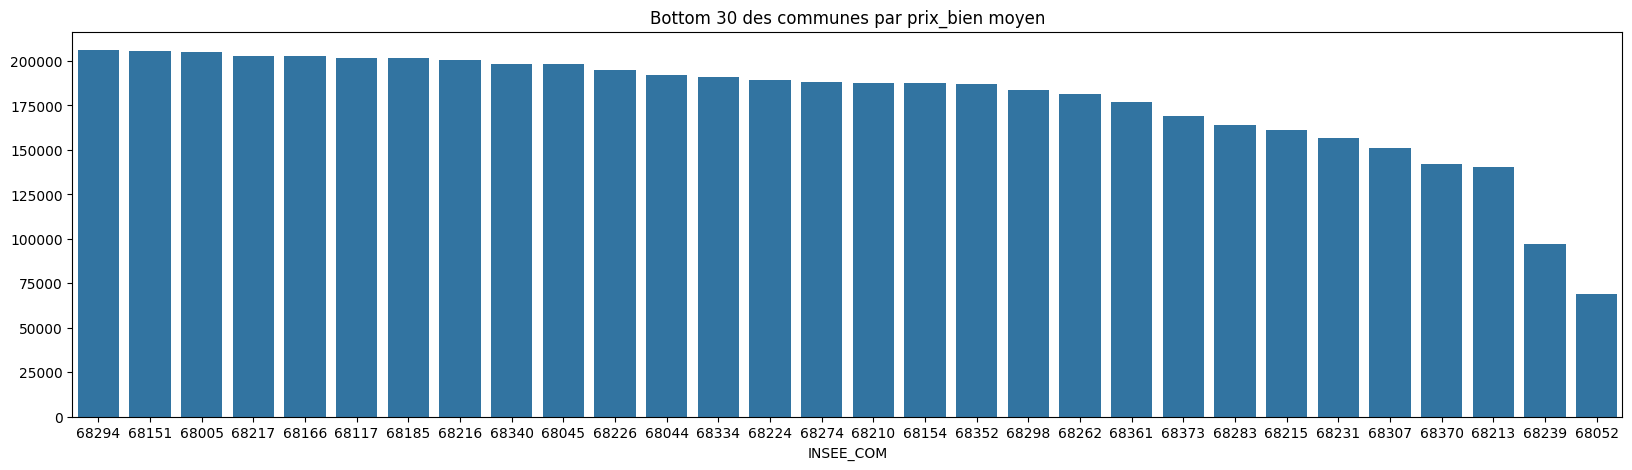

In [173]:
fig, ax = plt.subplots(figsize = (20,5))
group_commune = df_ventes.groupby('INSEE_COM')['prix_bien'].mean().sort_values(ascending=False)[-30:]

sns.barplot(x=group_commune.index, y=group_commune.values, order=group_commune.index)
plt.title('Bottom 30 des communes par prix_bien moyen');

La variable INSEE_COM influe sur le prix du bien mais il y a trop de modalités.

Nous devons trouver un moyen de regouper les communes entres elles.

# Etape 2 : Pre-processing et feature engineering

Attendue de cette étape :

* Suite aux constats établis lors de l’étape précédente, vous devrez nettoyer votre jeu de données et effectuer les étapes de pre-processing.
* Si besoin, il faudra transformer et/ou ajouter des features et enrichir votre jeu de données.
* L’objectif à la fin de cette étape est d’avoir un dataset prêt pour effectuer des analyses approfondies et/ou une modélisation à l’aide de Machine (et Deep) Learning.

**Pour la suite du projet, nous nous consentrerons sur les données de ventes (ech_annonces_ventes_68.csv)**

## Tâches pour Matthieu
* Rajouter les données géographiques
* Gestion des outliers

### Données géographiques

**Dans notre jeu de données, nous disposons des coordonnées GPS des logements :**

* mapCoordonneesLongitude
* mapCoordonneesLatitude

In [174]:
df_ventes_filtered[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']].head(10)

,mapCoordonneesLatitude,mapCoordonneesLongitude
idannonce,,
hektor-robischung-2862,47.55424,7.34766
apimo-82452515,48.17073,7.10498
immo-facile-52471952,48.16989,7.13037
immo-facile-52477215,48.17061,7.11870
ag681088-383601401,47.88536,7.19668
ag681104-381823822,47.54152,7.28713
hektor-robischung-2873,47.54331,7.29446
ag681158-383546936,47.91827,7.13488
ag751938-380728492,47.74310,7.33110


In [175]:
df_ventes_filtered[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']].describe()

,mapCoordonneesLatitude,mapCoordonneesLongitude
count,27737.000000,27737.000000
mean,47.805696,7.338446
std,0.181732,0.130714
min,47.427000,6.859940
25%,47.669290,7.274890
50%,47.759980,7.339940
75%,47.931890,7.405310
max,48.303780,7.616300


Nous avons des valeurs très rapprochées, dû à la nature de notre jeu de données se focalisant sur le département 68.

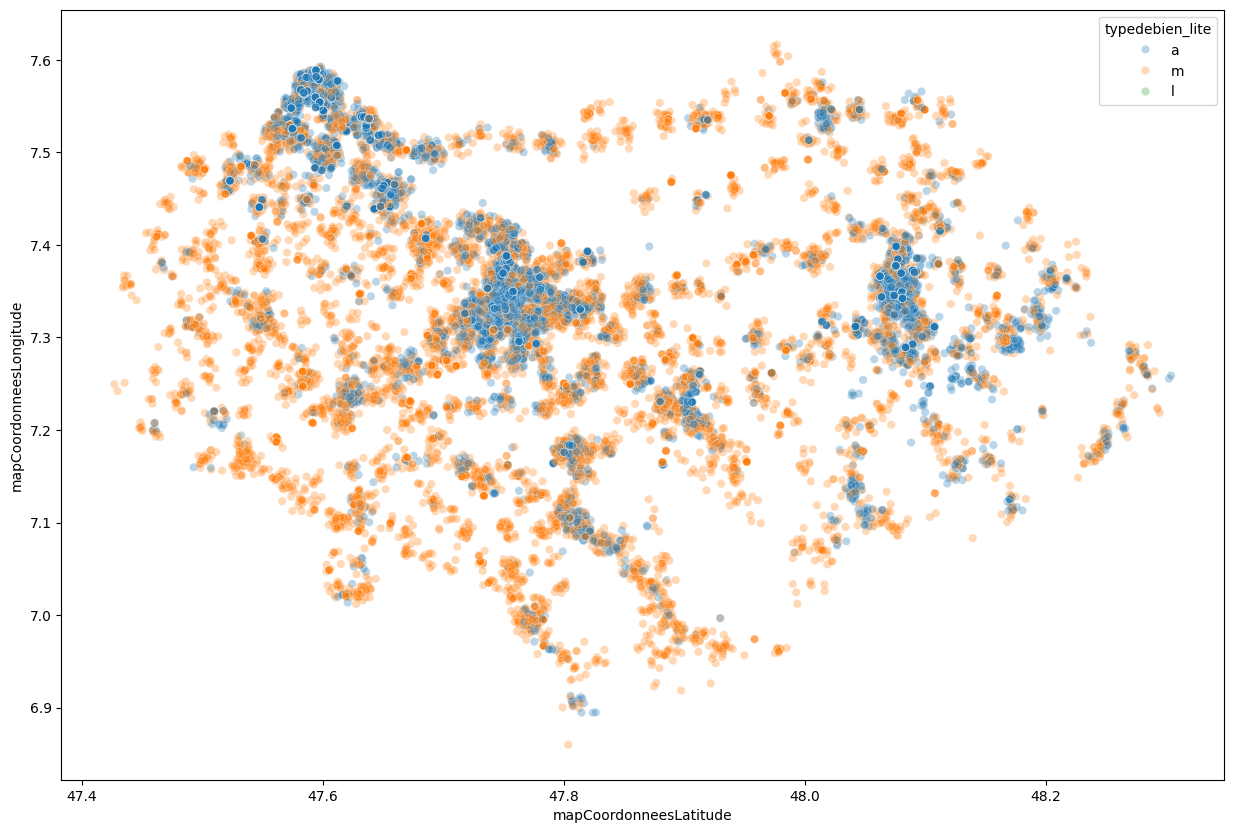

In [176]:
plt.figure(figsize=(15,10))
ax = sns.scatterplot(data=df_ventes_filtered, x='mapCoordonneesLatitude', y='mapCoordonneesLongitude', hue='typedebien_lite', alpha=0.3)

Avec un simple scatterplot, on observe déjà certaines concentrations d'appartements. Il s'agit très certainement de zones urbaines.

Carte des appartements :

In [177]:
import folium
from folium.plugins import MarkerCluster, HeatMap, FastMarkerCluster

df_ventes_filtered_appartement = df_ventes_filtered[df_ventes_filtered['typedebien_lite'] == 'a']

vente = [df_ventes_filtered_appartement['mapCoordonneesLatitude'].mean(), df_ventes_filtered_appartement['mapCoordonneesLongitude'].mean()]

min_lat = df_ventes_filtered_appartement['mapCoordonneesLatitude'].min()
max_lat = df_ventes_filtered_appartement['mapCoordonneesLatitude'].max()
min_lon = df_ventes_filtered_appartement['mapCoordonneesLongitude'].min()
max_lon = df_ventes_filtered_appartement['mapCoordonneesLongitude'].max()

# Créer la carte
m = folium.Map(
    location=vente,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# MarkerClusters directement ajoutés à la carte
marker_cluster = FastMarkerCluster(data=df_ventes_filtered_appartement[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']],).add_to(m)

HeatMap(df_ventes_filtered_appartement[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']], min_opacity=0.05).add_to(m)

m

Carte des maisons :

In [178]:
import folium
from folium.plugins import MarkerCluster, HeatMap, FastMarkerCluster

df_ventes_filtered_maison = df_ventes_filtered[df_ventes_filtered['typedebien_lite'] == 'm']

vente = [df_ventes_filtered_maison['mapCoordonneesLatitude'].mean(), df_ventes_filtered_maison['mapCoordonneesLongitude'].mean()]

min_lat = df_ventes_filtered_maison['mapCoordonneesLatitude'].min()
max_lat = df_ventes_filtered_maison['mapCoordonneesLatitude'].max()
min_lon = df_ventes_filtered_maison['mapCoordonneesLongitude'].min()
max_lon = df_ventes_filtered_maison['mapCoordonneesLongitude'].max()

# Créer la carte
m = folium.Map(
    location=vente,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# MarkerClusters directement ajoutés à la carte
marker_cluster = FastMarkerCluster(data=df_ventes_filtered_maison[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']],).add_to(m)

HeatMap(df_ventes_filtered_maison[['mapCoordonneesLatitude', 'mapCoordonneesLongitude']], min_opacity=0.05, blur=0).add_to(m)

m

On regarde maintenant la variable INSEE_COM (code de commune INSEE) :

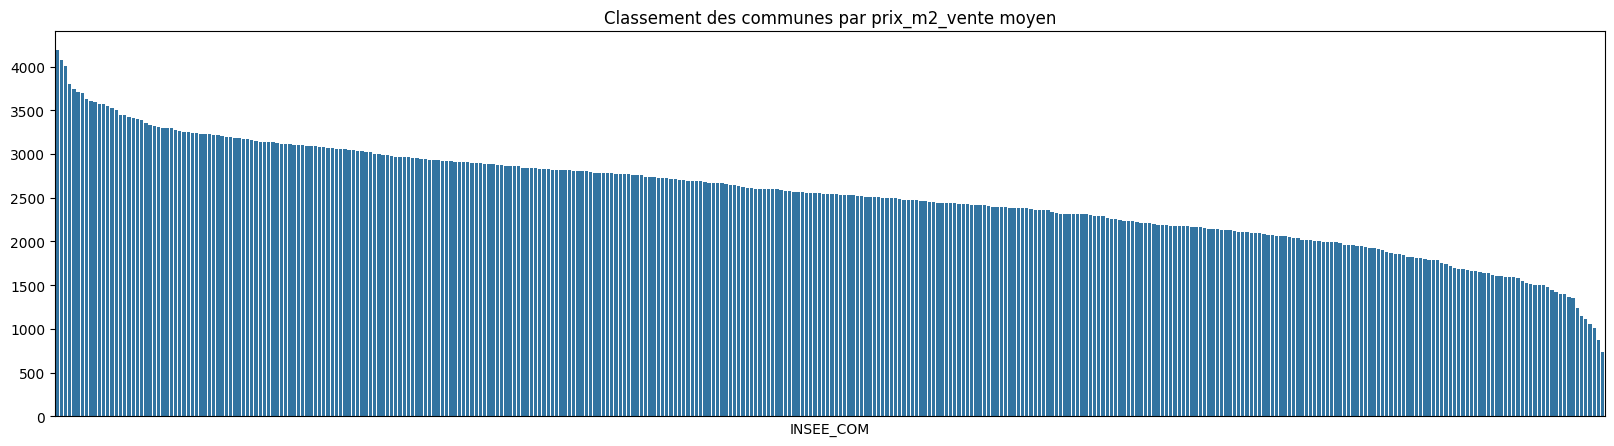

In [179]:
fig, ax = plt.subplots(figsize = (20,5))
top_com_prix_m2 = df_ventes_filtered.groupby('INSEE_COM')['prix_m2_vente'].mean().sort_values(ascending=False)

sns.barplot(x=top_com_prix_m2.index, y=top_com_prix_m2.values, order=top_com_prix_m2.index)
plt.xticks([])
plt.title('Classement des communes par prix_m2_vente moyen');

Nous pouvons associer à chaque INSEE_COM une moyenne ou médianne de prix_m2_vente => puis standardiser cette valeur

Le Target Encoding (ou Mean Encoding) consiste à remplacer chaque modalité d'une variable catégorielle par la moyenne de la variable cible (y) associée à cette modalité.

Ce type d'encodage est particulièrement utile pour les variables avec un grand nombre de catégories, là où le One-Hot Encoding peut devenir trop coûteux en mémoire.

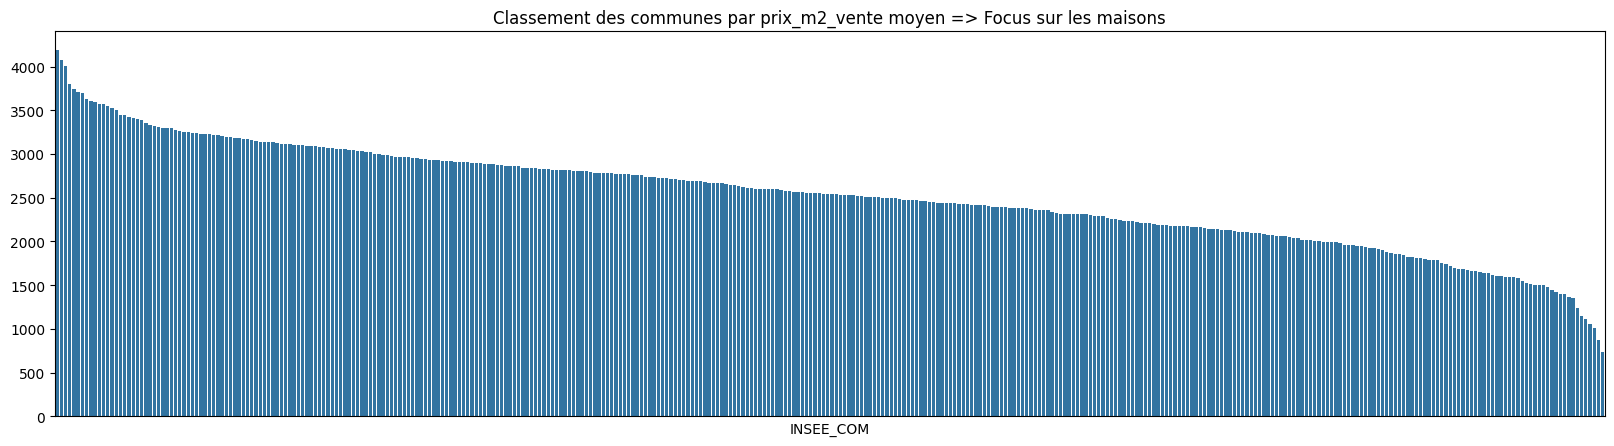

In [183]:
fig, ax = plt.subplots(figsize = (20,5))
top_com_prix_m2_maison = df_ventes_filtered[df_ventes_filtered['typedebien_lite'] == "m"].groupby('INSEE_COM')['prix_m2_vente'].mean().sort_values(ascending=False)

sns.barplot(x=top_com_prix_m2.index, y=top_com_prix_m2.values, order=top_com_prix_m2.index)
plt.xticks([])
plt.title('Classement des communes par prix_m2_vente moyen => Focus sur les maisons');

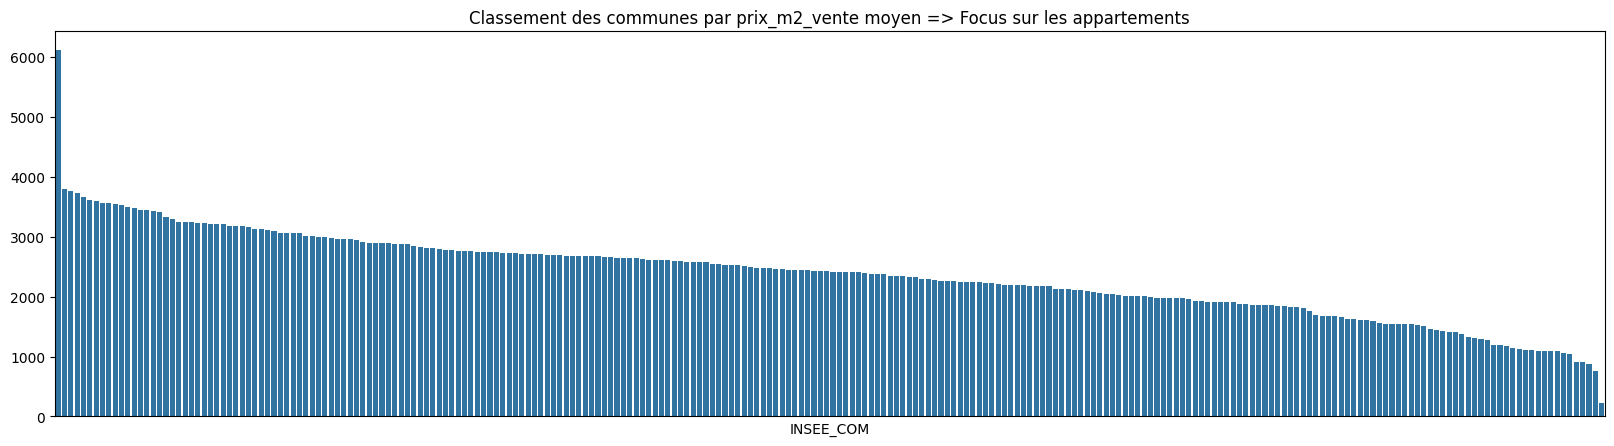

In [184]:
fig, ax = plt.subplots(figsize = (20,5))
top_com_prix_m2_appartement = df_ventes_filtered[df_ventes_filtered['typedebien_lite'] == "a"].groupby('INSEE_COM')['prix_m2_vente'].mean().sort_values(ascending=False)

sns.barplot(x=top_com_prix_m2_appartement.index, y=top_com_prix_m2_appartement.values, order=top_com_prix_m2_appartement.index)
plt.xticks([])
plt.title('Classement des communes par prix_m2_vente moyen => Focus sur les appartements');